# **Household Energy Consumption Prediction and High-Consumption Classification**

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    precision_recall_curve
)

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

RANDOM_STATE = 42

In [5]:
from google.colab import files
uploaded = files.upload()

Saving energydata_complete.csv to energydata_complete.csv


In [6]:
df = pd.read_csv("energydata_complete.csv")
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (19735, 29)


,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
0,2016-01-11 17:00:00,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,...,17.033333,45.53,6.600000,733.5,92.0,7.000000,63.000000,5.3,13.275433,13.275433
1,2016-01-11 17:10:00,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,...,17.066667,45.56,6.483333,733.6,92.0,6.666667,59.166667,5.2,18.606195,18.606195
2,2016-01-11 17:20:00,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,...,17.000000,45.50,6.366667,733.7,92.0,6.333333,55.333333,5.1,28.642668,28.642668
3,2016-01-11 17:30:00,50,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,...,17.000000,45.40,6.250000,733.8,92.0,6.000000,51.500000,5.0,45.410389,45.410389
4,2016-01-11 17:40:00,60,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,...,17.000000,45.40,6.133333,733.9,92.0,5.666667,47.666667,4.9,10.084097,10.084097


In [7]:
df.dtypes

,0
date,object
Appliances,int64
lights,int64
T1,float64
RH_1,float64
T2,float64
RH_2,float64
T3,float64
RH_3,float64
T4,float64


In [8]:
df.describe()

,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
count,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,...,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000
mean,97.694958,3.801875,21.686571,40.259739,20.341219,40.420420,22.267611,39.242500,20.855335,39.026904,...,19.485828,41.552401,7.411665,755.522602,79.750418,4.039752,38.330834,3.760707,24.988033,24.988033
std,102.524891,7.935988,1.606066,3.979299,2.192974,4.069813,2.006111,3.254576,2.042884,4.341321,...,2.014712,4.151497,5.317409,7.399441,14.901088,2.451221,11.794719,4.194648,14.496634,14.496634
min,10.000000,0.000000,16.790000,27.023333,16.100000,20.463333,17.200000,28.766667,15.100000,27.660000,...,14.890000,29.166667,-5.000000,729.300000,24.000000,0.000000,1.000000,-6.600000,0.005322,0.005322
25%,50.000000,0.000000,20.760000,37.333333,18.790000,37.900000,20.790000,36.900000,19.530000,35.530000,...,18.000000,38.500000,3.666667,750.933333,70.333333,2.000000,29.000000,0.900000,12.497889,12.497889
50%,60.000000,0.000000,21.600000,39.656667,20.000000,40.500000,22.100000,38.530000,20.666667,38.400000,...,19.390000,40.900000,6.916667,756.100000,83.666667,3.666667,40.000000,3.433333,24.897653,24.897653
75%,100.000000,0.000000,22.600000,43.066667,21.500000,43.260000,23.290000,41.760000,22.100000,42.156667,...,20.600000,44.338095,10.408333,760.933333,91.666667,5.500000,40.000000,6.566667,37.583769,37.583769
max,1080.000000,70.000000,26.260000,63.360000,29.856667,56.026667,29.236000,50.163333,26.200000,51.090000,...,24.500000,53.326667,26.100000,772.300000,100.000000,14.000000,66.000000,15.500000,49.996530,49.996530


## **Data Preprocessing**

In [9]:
df["date"] = pd.to_datetime(df["date"])
df["hour"] = df["date"].dt.hour
df["day"] = df["date"].dt.day
df["month"] = df["date"].dt.month
df["weekday"] = df["date"].dt.weekday
df = df.drop(columns=["date"])
df.head()

,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,...,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2,hour,day,month,weekday
0,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,45.566667,...,92.0,7.000000,63.000000,5.3,13.275433,13.275433,17,11,1,0
1,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,45.992500,...,92.0,6.666667,59.166667,5.2,18.606195,18.606195,17,11,1,0
2,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,45.890000,...,92.0,6.333333,55.333333,5.1,28.642668,28.642668,17,11,1,0
3,50,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,45.723333,...,92.0,6.000000,51.500000,5.0,45.410389,45.410389,17,11,1,0
4,60,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,45.530000,...,92.0,5.666667,47.666667,4.9,10.084097,10.084097,17,11,1,0


In [10]:
missing_values = df.isnull().sum()
missing_summary = missing_values[missing_values > 0]
print("Columns with missing values:")
print(missing_summary if len(missing_summary) > 0 else "No missing values found.")

Columns with missing values:
No missing values found.


In [11]:
if df.isnull().sum().sum() > 0:
    df = df.fillna(df.median(numeric_only=True))
    print("Missing values were imputed using the median of each column.")
else:
    print("No imputation required.")

No imputation required.


In [12]:
duplicate_count = df.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)

if duplicate_count > 0:
    df = df.drop_duplicates()
    print("Duplicates removed. New shape:", df.shape)

Number of duplicate rows: 0


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19735 entries, 0 to 19734
Data columns (total 32 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Appliances   19735 non-null  int64  
 1   lights       19735 non-null  int64  
 2   T1           19735 non-null  float64
 3   RH_1         19735 non-null  float64
 4   T2           19735 non-null  float64
 5   RH_2         19735 non-null  float64
 6   T3           19735 non-null  float64
 7   RH_3         19735 non-null  float64
 8   T4           19735 non-null  float64
 9   RH_4         19735 non-null  float64
 10  T5           19735 non-null  float64
 11  RH_5         19735 non-null  float64
 12  T6           19735 non-null  float64
 13  RH_6         19735 non-null  float64
 14  T7           19735 non-null  float64
 15  RH_7         19735 non-null  float64
 16  T8           19735 non-null  float64
 17  RH_8         19735 non-null  float64
 18  T9           19735 non-null  float64
 19  RH_9

## **Exploratory Data Analysis**

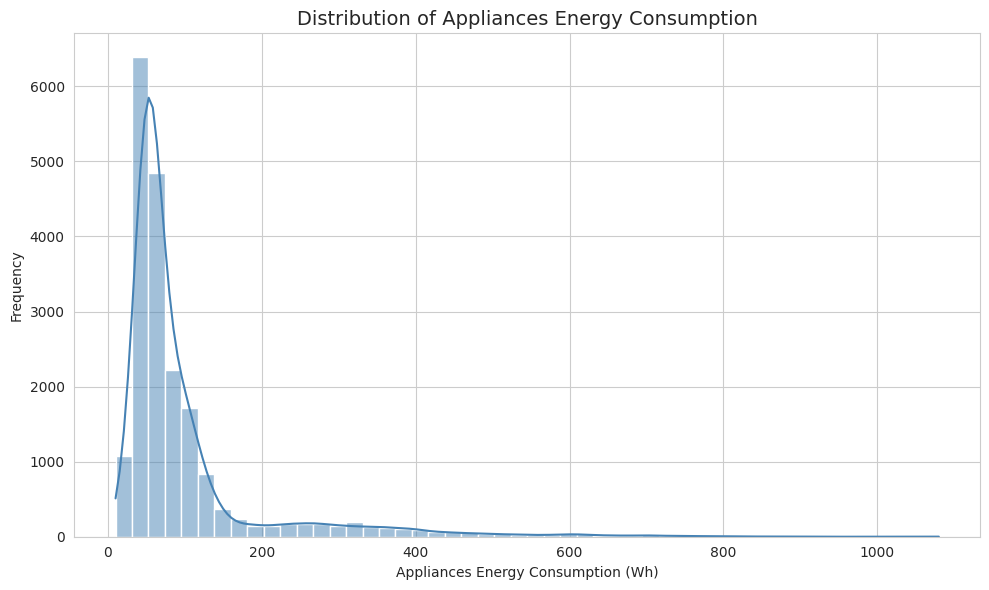

In [14]:
plt.figure(figsize=(10, 6))
sns.histplot(df["Appliances"], bins=50, kde=True, color="steelblue")
plt.title("Distribution of Appliances Energy Consumption", fontsize=14)
plt.xlabel("Appliances Energy Consumption (Wh)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

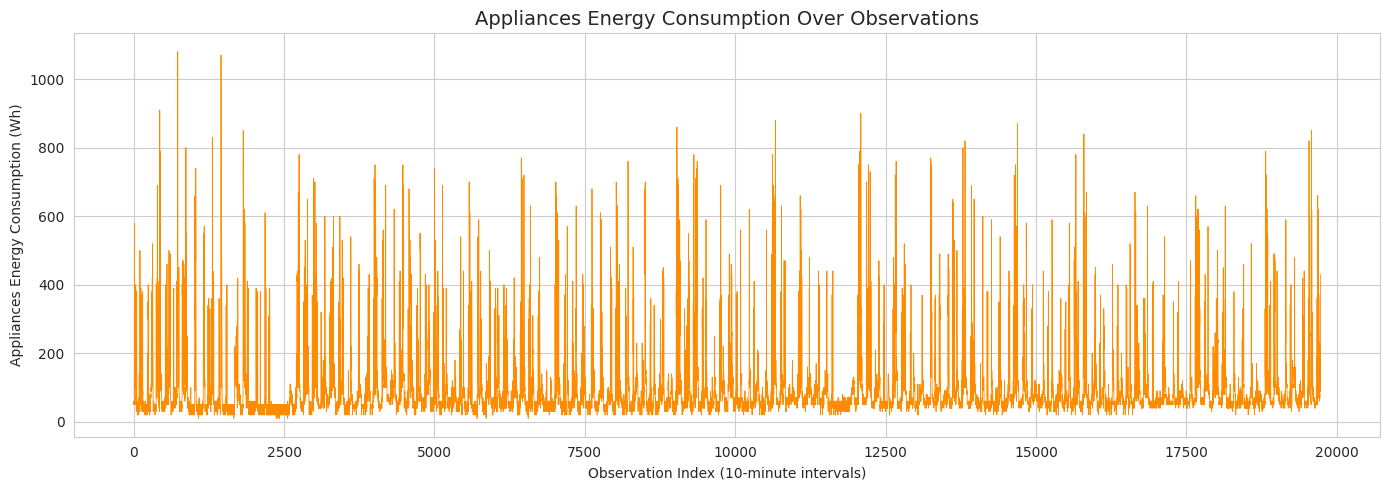

In [15]:
plt.figure(figsize=(14, 5))
plt.plot(df["Appliances"].values, color="darkorange", linewidth=0.6)
plt.title("Appliances Energy Consumption Over Observations", fontsize=14)
plt.xlabel("Observation Index (10-minute intervals)")
plt.ylabel("Appliances Energy Consumption (Wh)")
plt.tight_layout()
plt.show()

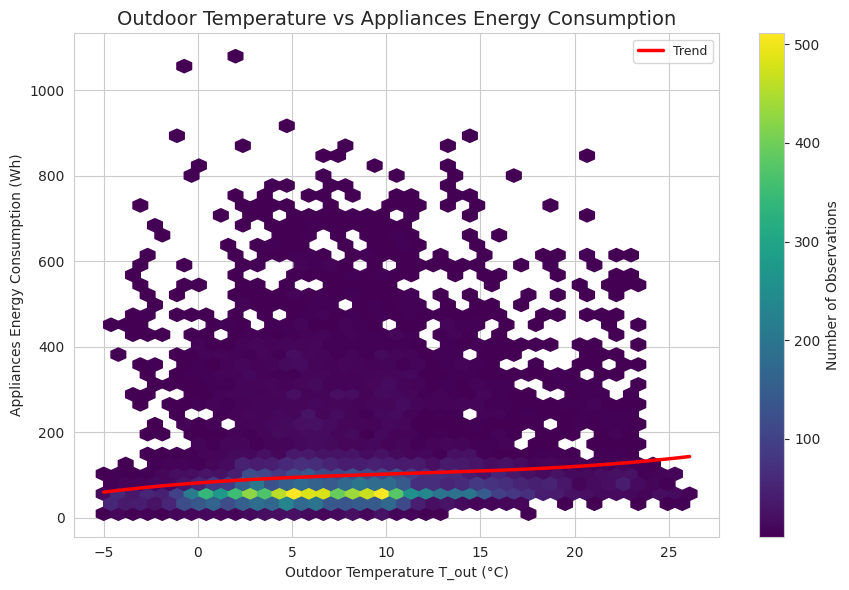

In [16]:
fig, ax = plt.subplots(figsize=(9, 6))
hb = ax.hexbin(df["T_out"], df["Appliances"], gridsize=40, cmap="viridis", mincnt=1)
trend_x = np.linspace(df["T_out"].min(), df["T_out"].max(), 200)
trend_coeffs = np.polyfit(df["T_out"], df["Appliances"], deg=3)
ax.plot(trend_x, np.polyval(trend_coeffs, trend_x), color="red", linewidth=2.5, label="Trend")
ax.legend(loc="upper right", fontsize=9)
cb = fig.colorbar(hb, ax=ax)
cb.set_label("Number of Observations")
ax.set_title("Outdoor Temperature vs Appliances Energy Consumption", fontsize=14)
ax.set_xlabel("Outdoor Temperature T_out (°C)")
ax.set_ylabel("Appliances Energy Consumption (Wh)")
plt.tight_layout()
plt.show()

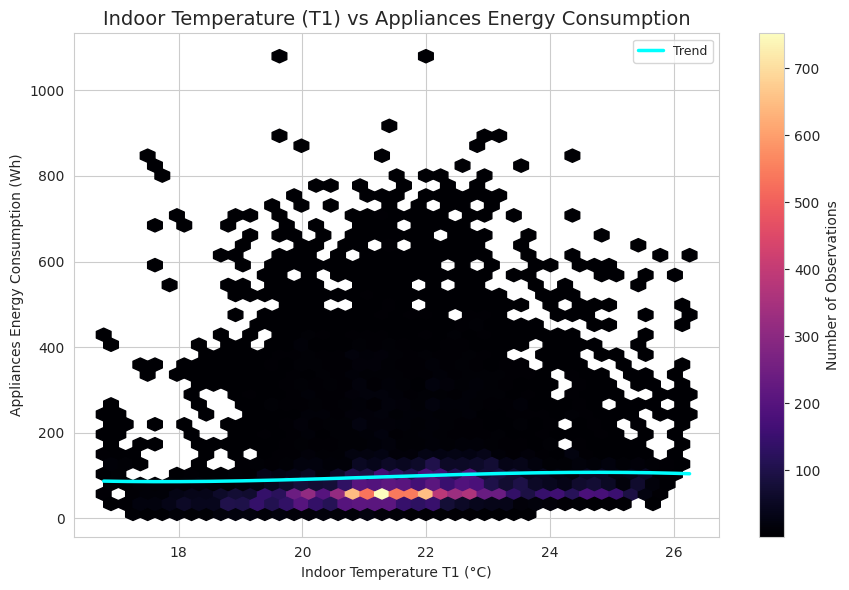

In [17]:
fig, ax = plt.subplots(figsize=(9, 6))
hb = ax.hexbin(df["T1"], df["Appliances"], gridsize=40, cmap="magma", mincnt=1)
trend_x = np.linspace(df["T1"].min(), df["T1"].max(), 200)
trend_coeffs = np.polyfit(df["T1"], df["Appliances"], deg=3)
ax.plot(trend_x, np.polyval(trend_coeffs, trend_x), color="cyan", linewidth=2.5, label="Trend")
ax.legend(loc="upper right", fontsize=9)
cb = fig.colorbar(hb, ax=ax)
cb.set_label("Number of Observations")
ax.set_title("Indoor Temperature (T1) vs Appliances Energy Consumption", fontsize=14)
ax.set_xlabel("Indoor Temperature T1 (°C)")
ax.set_ylabel("Appliances Energy Consumption (Wh)")
plt.tight_layout()
plt.show()

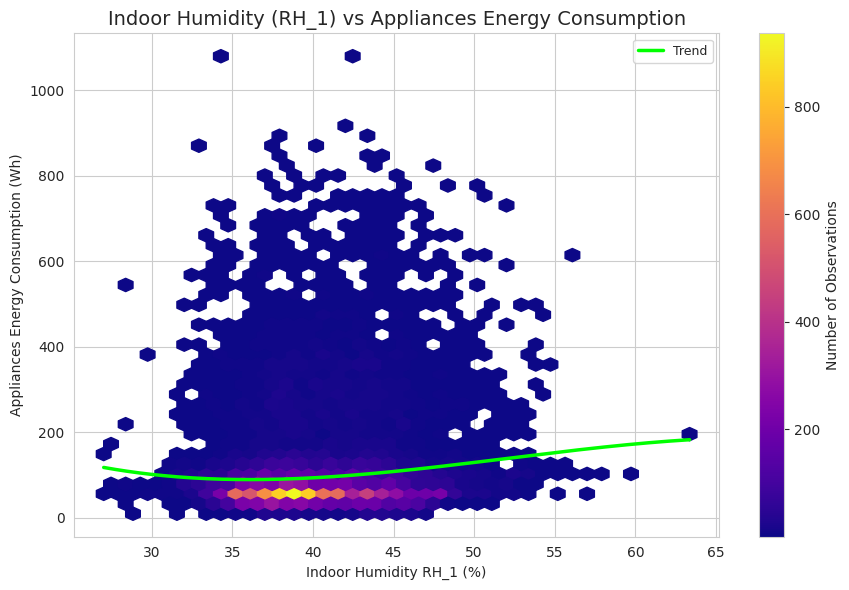

In [18]:
fig, ax = plt.subplots(figsize=(9, 6))
hb = ax.hexbin(df["RH_1"], df["Appliances"], gridsize=40, cmap="plasma", mincnt=1)
trend_x = np.linspace(df["RH_1"].min(), df["RH_1"].max(), 200)
trend_coeffs = np.polyfit(df["RH_1"], df["Appliances"], deg=3)
ax.plot(trend_x, np.polyval(trend_coeffs, trend_x), color="lime", linewidth=2.5, label="Trend")
ax.legend(loc="upper right", fontsize=9)
cb = fig.colorbar(hb, ax=ax)
cb.set_label("Number of Observations")
ax.set_title("Indoor Humidity (RH_1) vs Appliances Energy Consumption", fontsize=14)
ax.set_xlabel("Indoor Humidity RH_1 (%)")
ax.set_ylabel("Appliances Energy Consumption (Wh)")
plt.tight_layout()
plt.show()

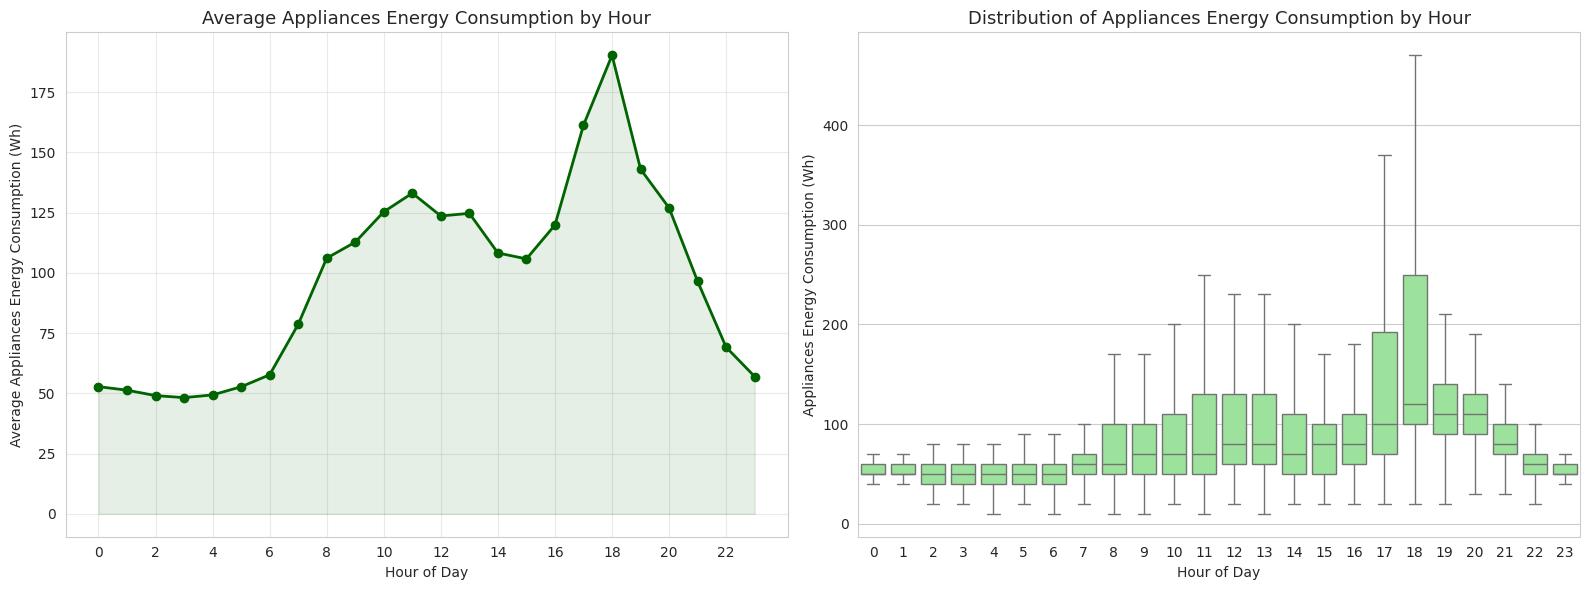

In [19]:
hourly_avg = df.groupby("hour")["Appliances"].mean()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].plot(hourly_avg.index, hourly_avg.values, marker="o", color="darkgreen", linewidth=2)
axes[0].fill_between(hourly_avg.index, hourly_avg.values, color="darkgreen", alpha=0.1)
axes[0].set_title("Average Appliances Energy Consumption by Hour", fontsize=13)
axes[0].set_xlabel("Hour of Day")
axes[0].set_ylabel("Average Appliances Energy Consumption (Wh)")
axes[0].set_xticks(range(0, 24, 2))
axes[0].grid(True, alpha=0.4)

sns.boxplot(x="hour", y="Appliances", data=df, ax=axes[1], color="lightgreen", showfliers=False)
axes[1].set_title("Distribution of Appliances Energy Consumption by Hour", fontsize=13)
axes[1].set_xlabel("Hour of Day")
axes[1].set_ylabel("Appliances Energy Consumption (Wh)")

plt.tight_layout()
plt.show()

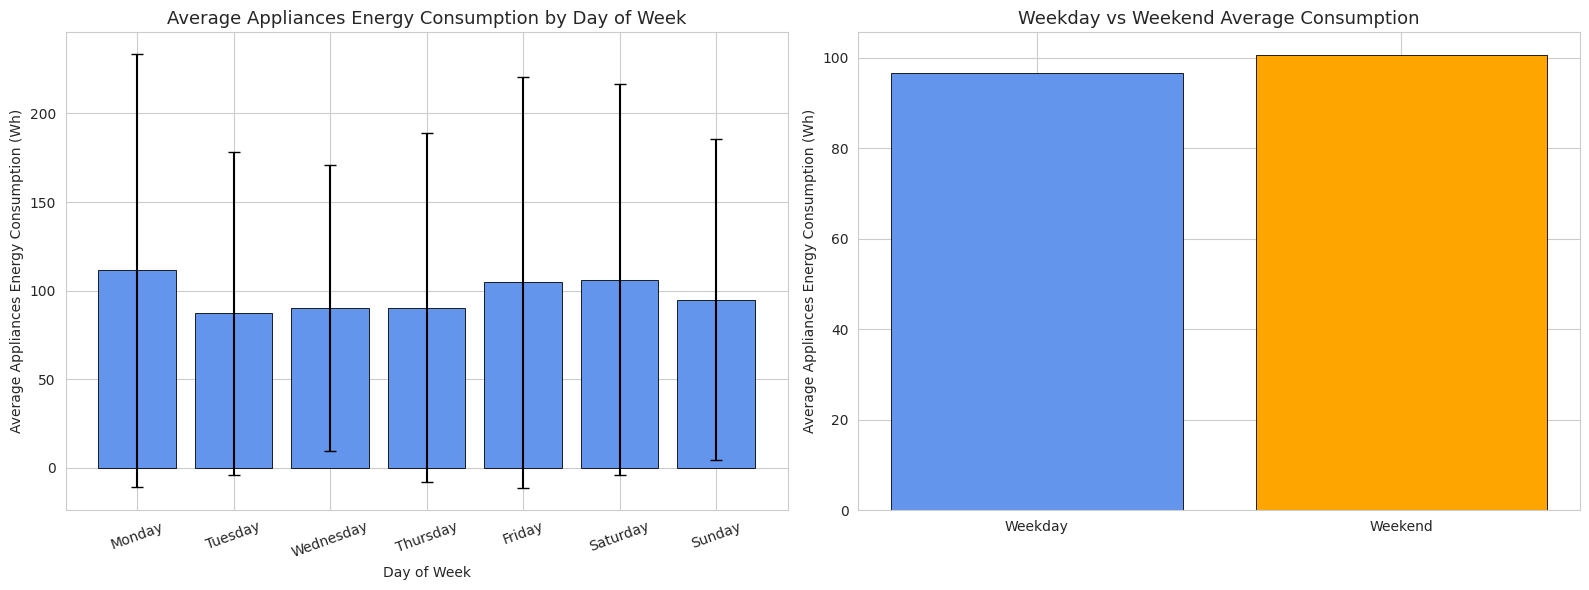

In [20]:
weekday_labels = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
weekday_avg = df.groupby("weekday")["Appliances"].mean()
weekday_std = df.groupby("weekday")["Appliances"].std()

weekend_labels = df["weekday"].isin([5, 6]).map({True: "Weekend", False: "Weekday"})
weekend_avg = df["Appliances"].groupby(weekend_labels).mean()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].bar(weekday_labels, weekday_avg.values, yerr=weekday_std.values, capsize=4,
            color="cornflowerblue", edgecolor="black", linewidth=0.6)
axes[0].set_title("Average Appliances Energy Consumption by Day of Week", fontsize=13)
axes[0].set_xlabel("Day of Week")
axes[0].set_ylabel("Average Appliances Energy Consumption (Wh)")
axes[0].tick_params(axis="x", rotation=20)

axes[1].bar(weekend_avg.index, weekend_avg.values, color=["cornflowerblue", "orange"], edgecolor="black", linewidth=0.6)
axes[1].set_title("Weekday vs Weekend Average Consumption", fontsize=13)
axes[1].set_ylabel("Average Appliances Energy Consumption (Wh)")

plt.tight_layout()
plt.show()

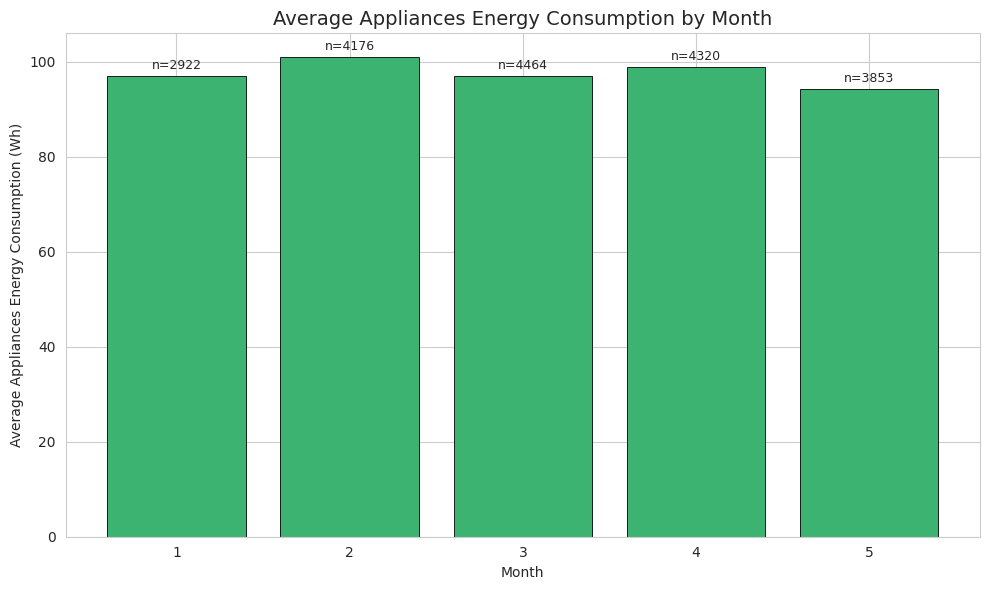

In [21]:
monthly_avg = df.groupby("month")["Appliances"].mean()
monthly_count = df.groupby("month")["Appliances"].count()

fig, ax1 = plt.subplots(figsize=(10, 6))
bars = ax1.bar(monthly_avg.index.astype(str), monthly_avg.values, color="mediumseagreen", edgecolor="black", linewidth=0.6)
ax1.set_title("Average Appliances Energy Consumption by Month", fontsize=14)
ax1.set_xlabel("Month")
ax1.set_ylabel("Average Appliances Energy Consumption (Wh)")

for bar, count in zip(bars, monthly_count.values):
    ax1.annotate(f"n={count}", (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                 textcoords="offset points", xytext=(0, 5), ha="center", fontsize=9)

plt.tight_layout()
plt.show()

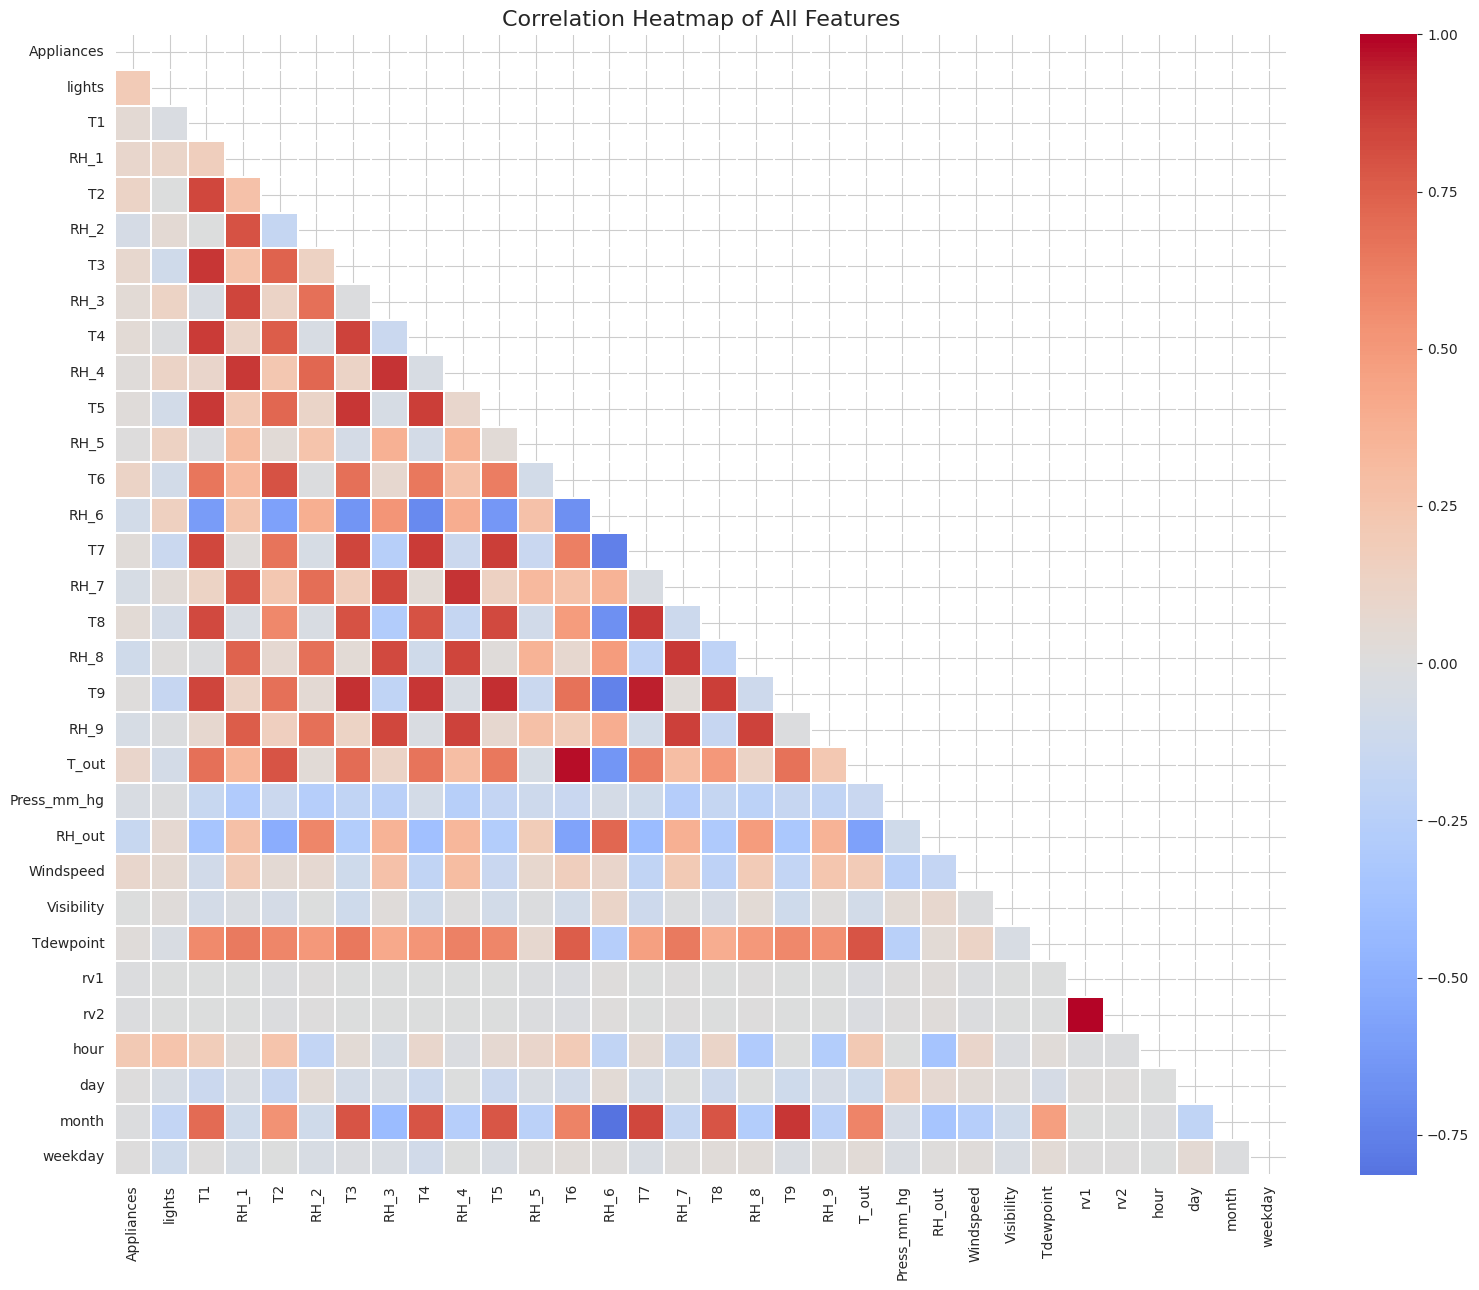

In [22]:
plt.figure(figsize=(16, 13))
correlation_matrix = df.corr()
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, cmap="coolwarm", center=0, annot=False, linewidths=0.3, mask=mask)
plt.title("Correlation Heatmap of All Features", fontsize=16)
plt.tight_layout()
plt.show()

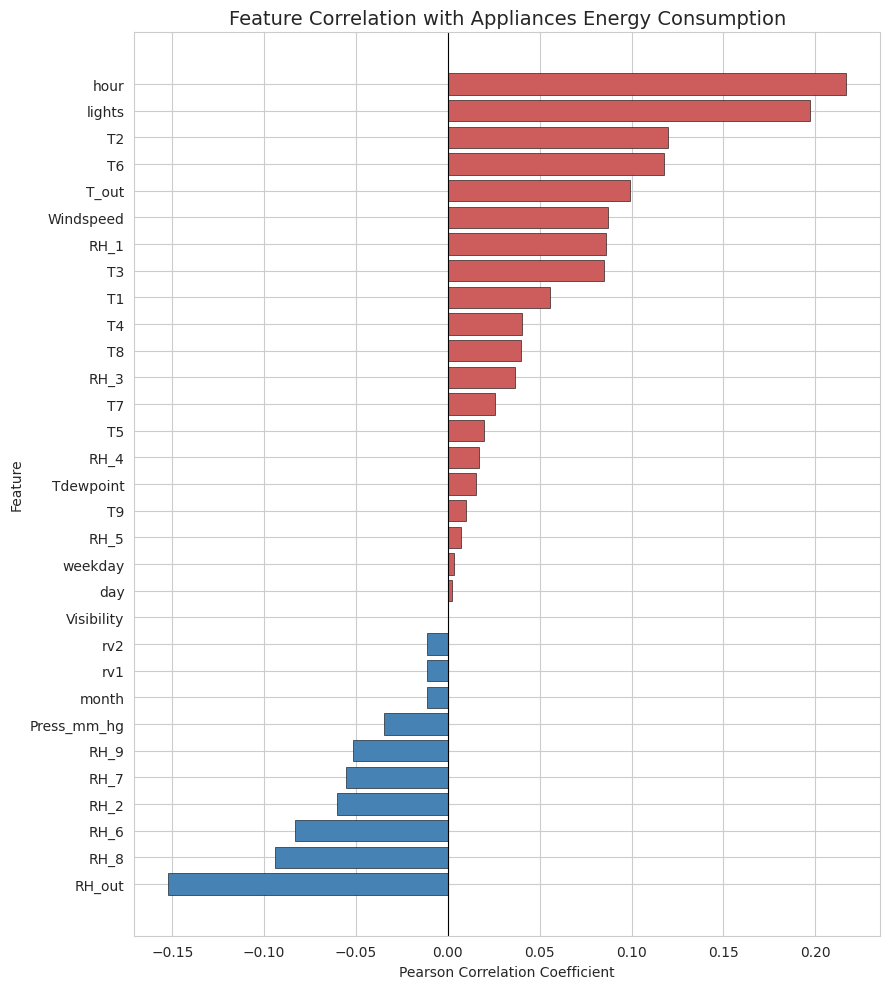

In [23]:
target_correlation = correlation_matrix["Appliances"].drop("Appliances").sort_values()

plt.figure(figsize=(9, 10))
colors = ["indianred" if v > 0 else "steelblue" for v in target_correlation.values]
plt.barh(target_correlation.index, target_correlation.values, color=colors, edgecolor="black", linewidth=0.4)
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Feature Correlation with Appliances Energy Consumption", fontsize=14)
plt.xlabel("Pearson Correlation Coefficient")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

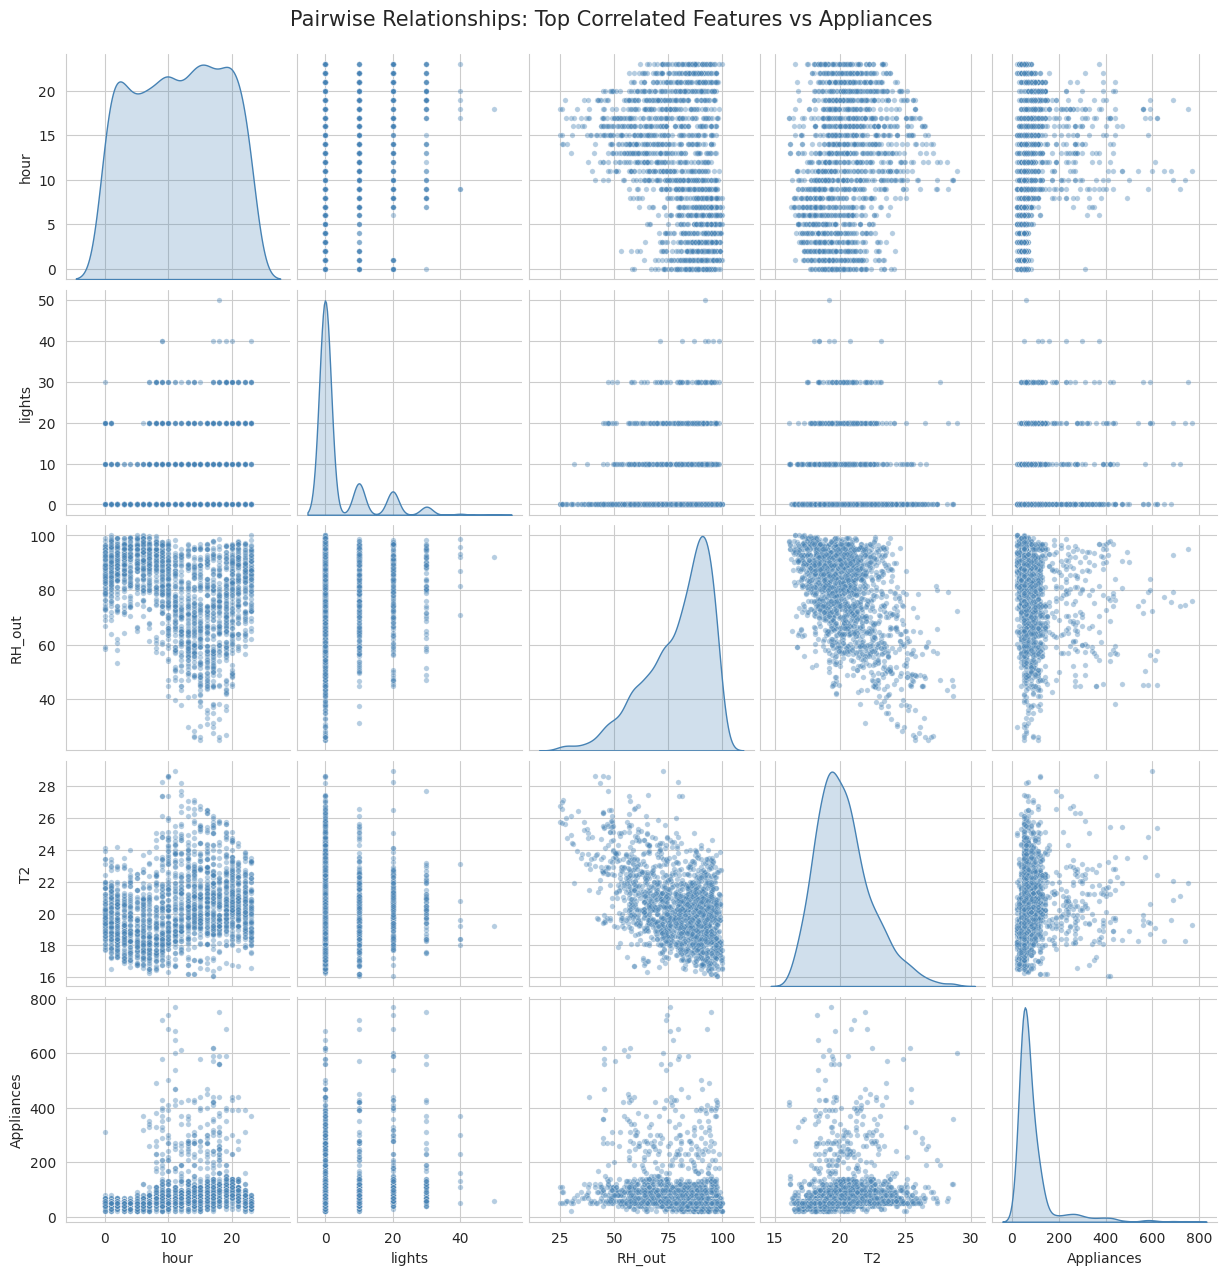

In [24]:
top_corr_features = target_correlation.abs().sort_values(ascending=False).head(4).index.tolist()
pairplot_columns = top_corr_features + ["Appliances"]

pairplot_fig = sns.pairplot(
    df[pairplot_columns].sample(min(2000, len(df)), random_state=RANDOM_STATE),
    diag_kind="kde",
    plot_kws={"alpha": 0.4, "s": 15, "color": "steelblue"},
    diag_kws={"color": "steelblue"}
)
pairplot_fig.fig.suptitle("Pairwise Relationships: Top Correlated Features vs Appliances", y=1.02, fontsize=15)
plt.show()

In [25]:
X_reg = df.drop(columns=["Appliances"])
y_reg = df["Appliances"]

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=RANDOM_STATE
)

scaler_reg = StandardScaler()
X_train_reg_scaled = scaler_reg.fit_transform(X_train_reg)
X_test_reg_scaled = scaler_reg.transform(X_test_reg)

print("Training set shape:", X_train_reg.shape)
print("Test set shape:", X_test_reg.shape)

Training set shape: (15788, 31)
Test set shape: (3947, 31)


In [26]:
def regression_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    return {"MAE": mae, "MSE": mse, "RMSE": rmse, "R2": r2}

regression_results = {}
regression_predictions = {}

## **Linear Regression**

In [27]:
lin_reg = LinearRegression()
lin_reg.fit(X_train_reg_scaled, y_train_reg)
y_pred_lin = lin_reg.predict(X_test_reg_scaled)

regression_results["Linear Regression"] = regression_metrics(y_test_reg, y_pred_lin)
regression_predictions["Linear Regression"] = y_pred_lin

pd.DataFrame(regression_results).T

,MAE,MSE,RMSE,R2
Linear Regression,52.569734,8303.540929,91.123767,0.170234


## **Polynomial Regression**


In [28]:
poly_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("linreg", LinearRegression())
])

poly_pipeline.fit(X_train_reg, y_train_reg)
y_pred_poly = poly_pipeline.predict(X_test_reg)

regression_results["Polynomial Regression"] = regression_metrics(y_test_reg, y_pred_poly)
regression_predictions["Polynomial Regression"] = y_pred_poly

pd.DataFrame({"Polynomial Regression": regression_results["Polynomial Regression"]}).T

,MAE,MSE,RMSE,R2
Polynomial Regression,48.753069,6796.38611,82.440197,0.320843


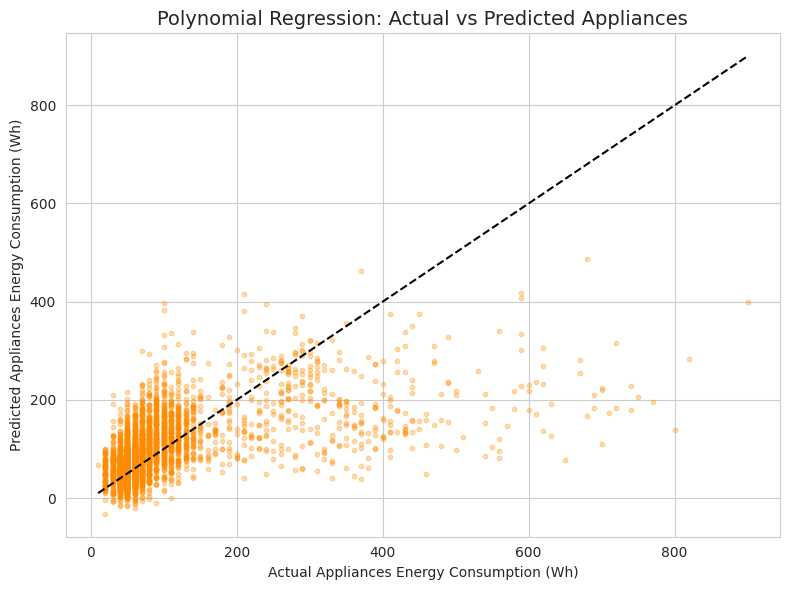

In [29]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test_reg, y_pred_poly, alpha=0.3, s=10, color="darkorange")
plt.plot(
    [y_test_reg.min(), y_test_reg.max()],
    [y_test_reg.min(), y_test_reg.max()],
    color="black",
    linestyle="--"
)
plt.title("Polynomial Regression: Actual vs Predicted Appliances", fontsize=14)
plt.xlabel("Actual Appliances Energy Consumption (Wh)")
plt.ylabel("Predicted Appliances Energy Consumption (Wh)")
plt.tight_layout()
plt.show()

## **Ridge Regression**

In [30]:
ridge_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=1.0, random_state=RANDOM_STATE))
])

ridge_pipeline.fit(X_train_reg, y_train_reg)
y_pred_ridge = ridge_pipeline.predict(X_test_reg)

regression_results["Ridge Regression"] = regression_metrics(y_test_reg, y_pred_ridge)
regression_predictions["Ridge Regression"] = y_pred_ridge

pd.DataFrame({"Ridge Regression": regression_results["Ridge Regression"]}).T

,MAE,MSE,RMSE,R2
Ridge Regression,52.565697,8303.323373,91.122573,0.170256


## **Lasso Regression**

In [31]:
lasso_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("lasso", Lasso(alpha=0.1, max_iter=10000, random_state=RANDOM_STATE))
])

lasso_pipeline.fit(X_train_reg, y_train_reg)
y_pred_lasso = lasso_pipeline.predict(X_test_reg)

regression_results["Lasso Regression"] = regression_metrics(y_test_reg, y_pred_lasso)
regression_predictions["Lasso Regression"] = y_pred_lasso

pd.DataFrame({"Lasso Regression": regression_results["Lasso Regression"]}).T

,MAE,MSE,RMSE,R2
Lasso Regression,52.439292,8298.148076,91.094171,0.170773


## **Regression Model Comparison**

In [32]:
regression_comparison = pd.DataFrame(regression_results).T
regression_comparison = regression_comparison[["MAE", "MSE", "RMSE", "R2"]]
regression_comparison

,MAE,MSE,RMSE,R2
Linear Regression,52.569734,8303.540929,91.123767,0.170234
Polynomial Regression,48.753069,6796.386110,82.440197,0.320843
Ridge Regression,52.565697,8303.323373,91.122573,0.170256
Lasso Regression,52.439292,8298.148076,91.094171,0.170773


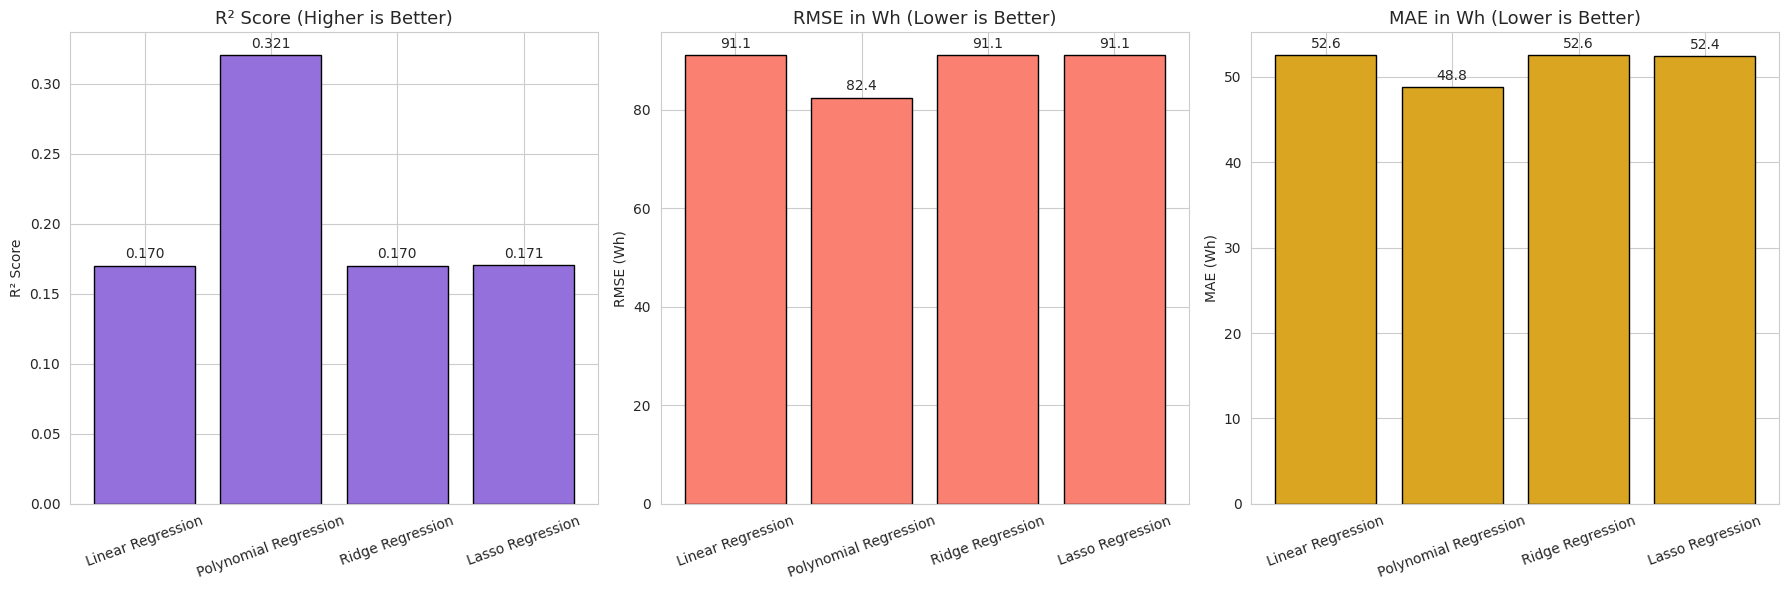

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

bars0 = axes[0].bar(regression_comparison.index, regression_comparison["R2"], color="mediumpurple", edgecolor="black")
axes[0].set_title("R² Score (Higher is Better)", fontsize=13)
axes[0].set_ylabel("R² Score")
axes[0].tick_params(axis="x", rotation=20)
axes[0].bar_label(bars0, fmt="%.3f", padding=3)

bars1 = axes[1].bar(regression_comparison.index, regression_comparison["RMSE"], color="salmon", edgecolor="black")
axes[1].set_title("RMSE in Wh (Lower is Better)", fontsize=13)
axes[1].set_ylabel("RMSE (Wh)")
axes[1].tick_params(axis="x", rotation=20)
axes[1].bar_label(bars1, fmt="%.1f", padding=3)

bars2 = axes[2].bar(regression_comparison.index, regression_comparison["MAE"], color="goldenrod", edgecolor="black")
axes[2].set_title("MAE in Wh (Lower is Better)", fontsize=13)
axes[2].set_ylabel("MAE (Wh)")
axes[2].tick_params(axis="x", rotation=20)
axes[2].bar_label(bars2, fmt="%.1f", padding=3)

plt.tight_layout()
plt.show()

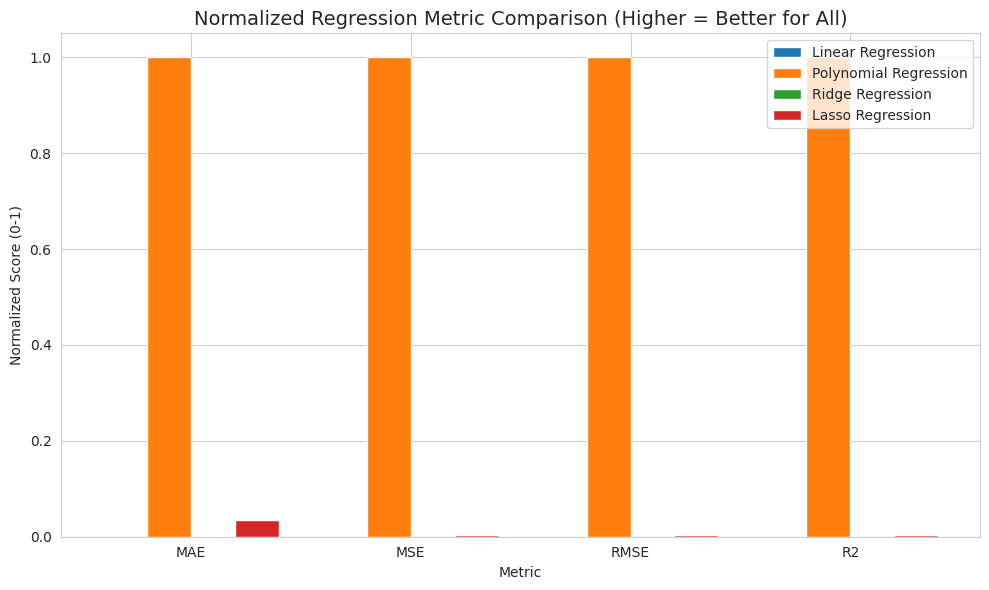

In [34]:
normalized_comparison = regression_comparison.copy()
for col in ["MAE", "MSE", "RMSE"]:
    normalized_comparison[col] = 1 - (normalized_comparison[col] - normalized_comparison[col].min()) / (normalized_comparison[col].max() - normalized_comparison[col].min() + 1e-9)
normalized_comparison["R2"] = (normalized_comparison["R2"] - normalized_comparison["R2"].min()) / (normalized_comparison["R2"].max() - normalized_comparison["R2"].min() + 1e-9)

metrics_order = ["MAE", "MSE", "RMSE", "R2"]
x = np.arange(len(metrics_order))
width = 0.8 / len(normalized_comparison)

plt.figure(figsize=(10, 6))
for i, model_name in enumerate(normalized_comparison.index):
    plt.bar(x + i * width, normalized_comparison.loc[model_name, metrics_order], width=width, label=model_name)

plt.title("Normalized Regression Metric Comparison (Higher = Better for All)", fontsize=14)
plt.xlabel("Metric")
plt.ylabel("Normalized Score (0-1)")
plt.xticks(x + width * (len(normalized_comparison) - 1) / 2, metrics_order)
plt.legend()
plt.tight_layout()
plt.show()

In [35]:
best_regression_model = regression_comparison["R2"].idxmax()
print("Best regression model based on R2 score:", best_regression_model)
print(regression_comparison.loc[best_regression_model])

Best regression model based on R2 score: Polynomial Regression
MAE       48.753069
MSE     6796.386110
RMSE      82.440197
R2         0.320843
Name: Polynomial Regression, dtype: float64


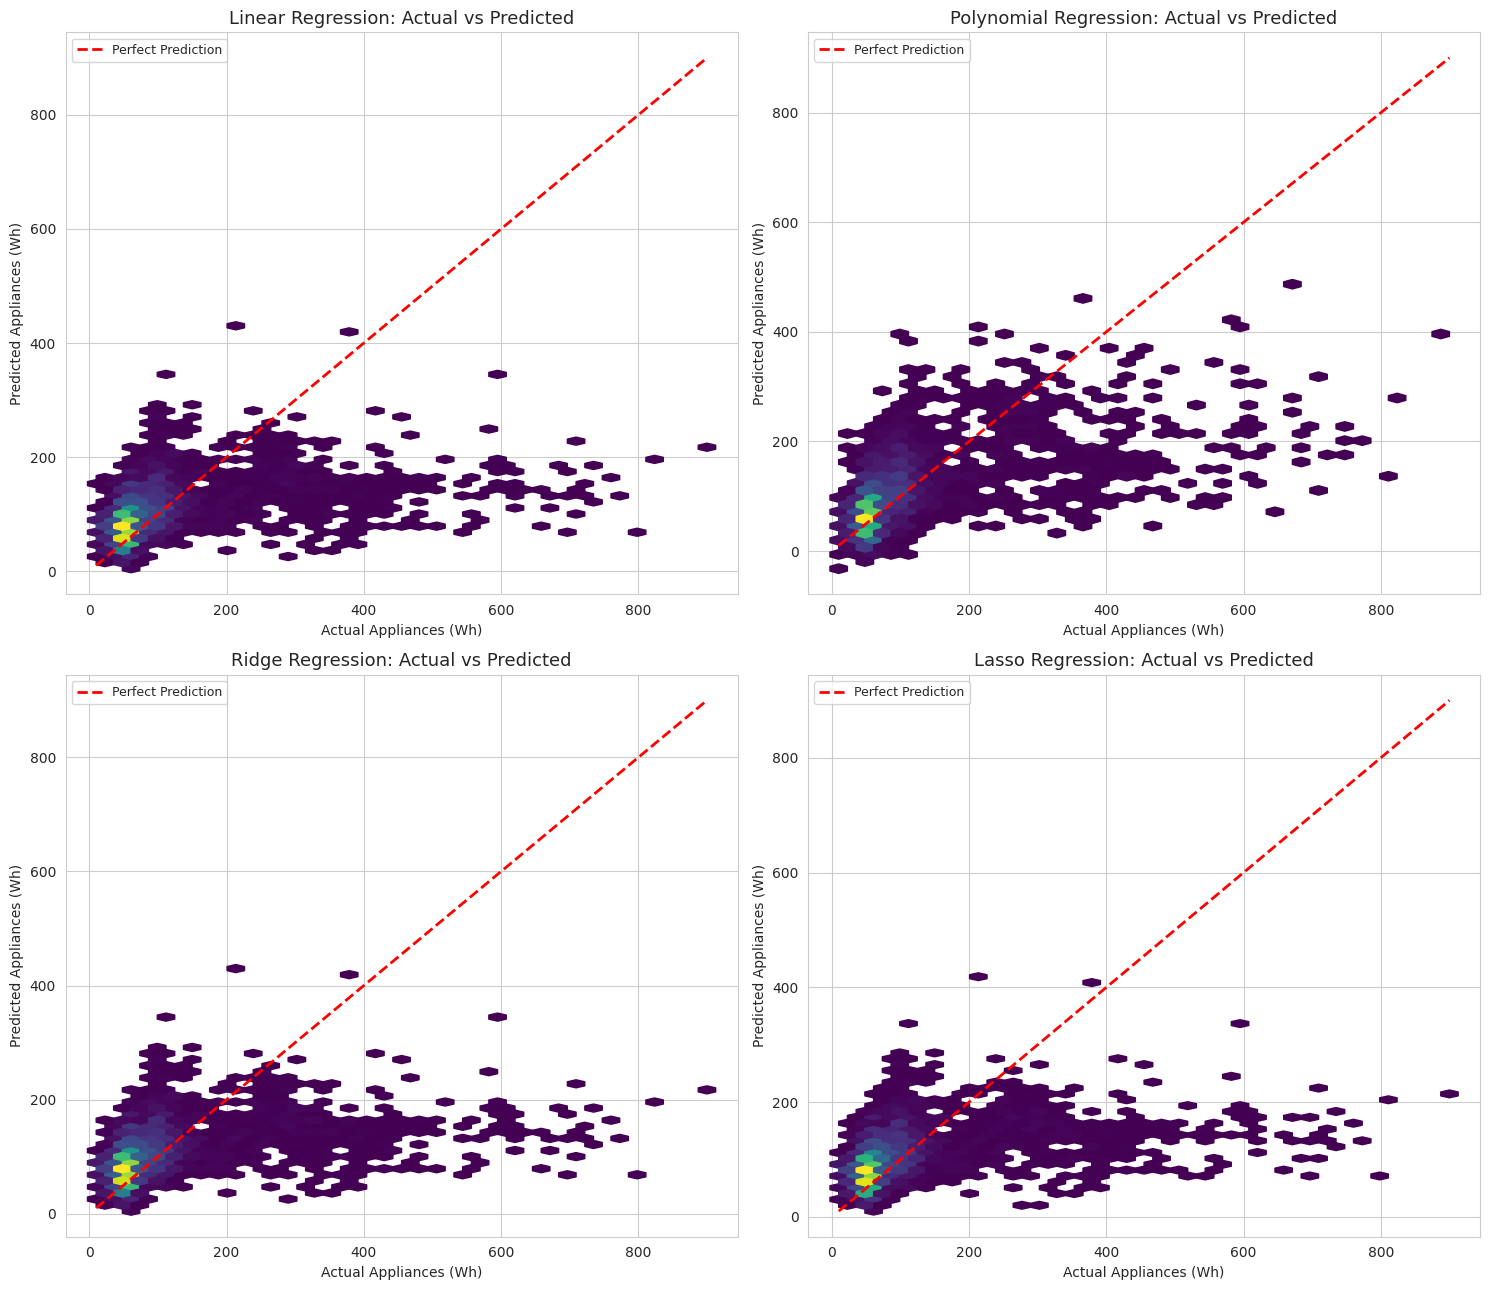

In [36]:
fig, axes = plt.subplots(2, 2, figsize=(15, 13))
axes = axes.flatten()

for ax, (model_name, y_pred) in zip(axes, regression_predictions.items()):
    hb = ax.hexbin(y_test_reg, y_pred, gridsize=35, cmap="viridis", mincnt=1)
    ax.plot(
        [y_test_reg.min(), y_test_reg.max()],
        [y_test_reg.min(), y_test_reg.max()],
        color="red",
        linestyle="--",
        linewidth=2,
        label="Perfect Prediction"
    )
    ax.set_title(f"{model_name}: Actual vs Predicted", fontsize=13)
    ax.set_xlabel("Actual Appliances (Wh)")
    ax.set_ylabel("Predicted Appliances (Wh)")
    ax.legend(loc="upper left", fontsize=9)

plt.tight_layout()
plt.show()

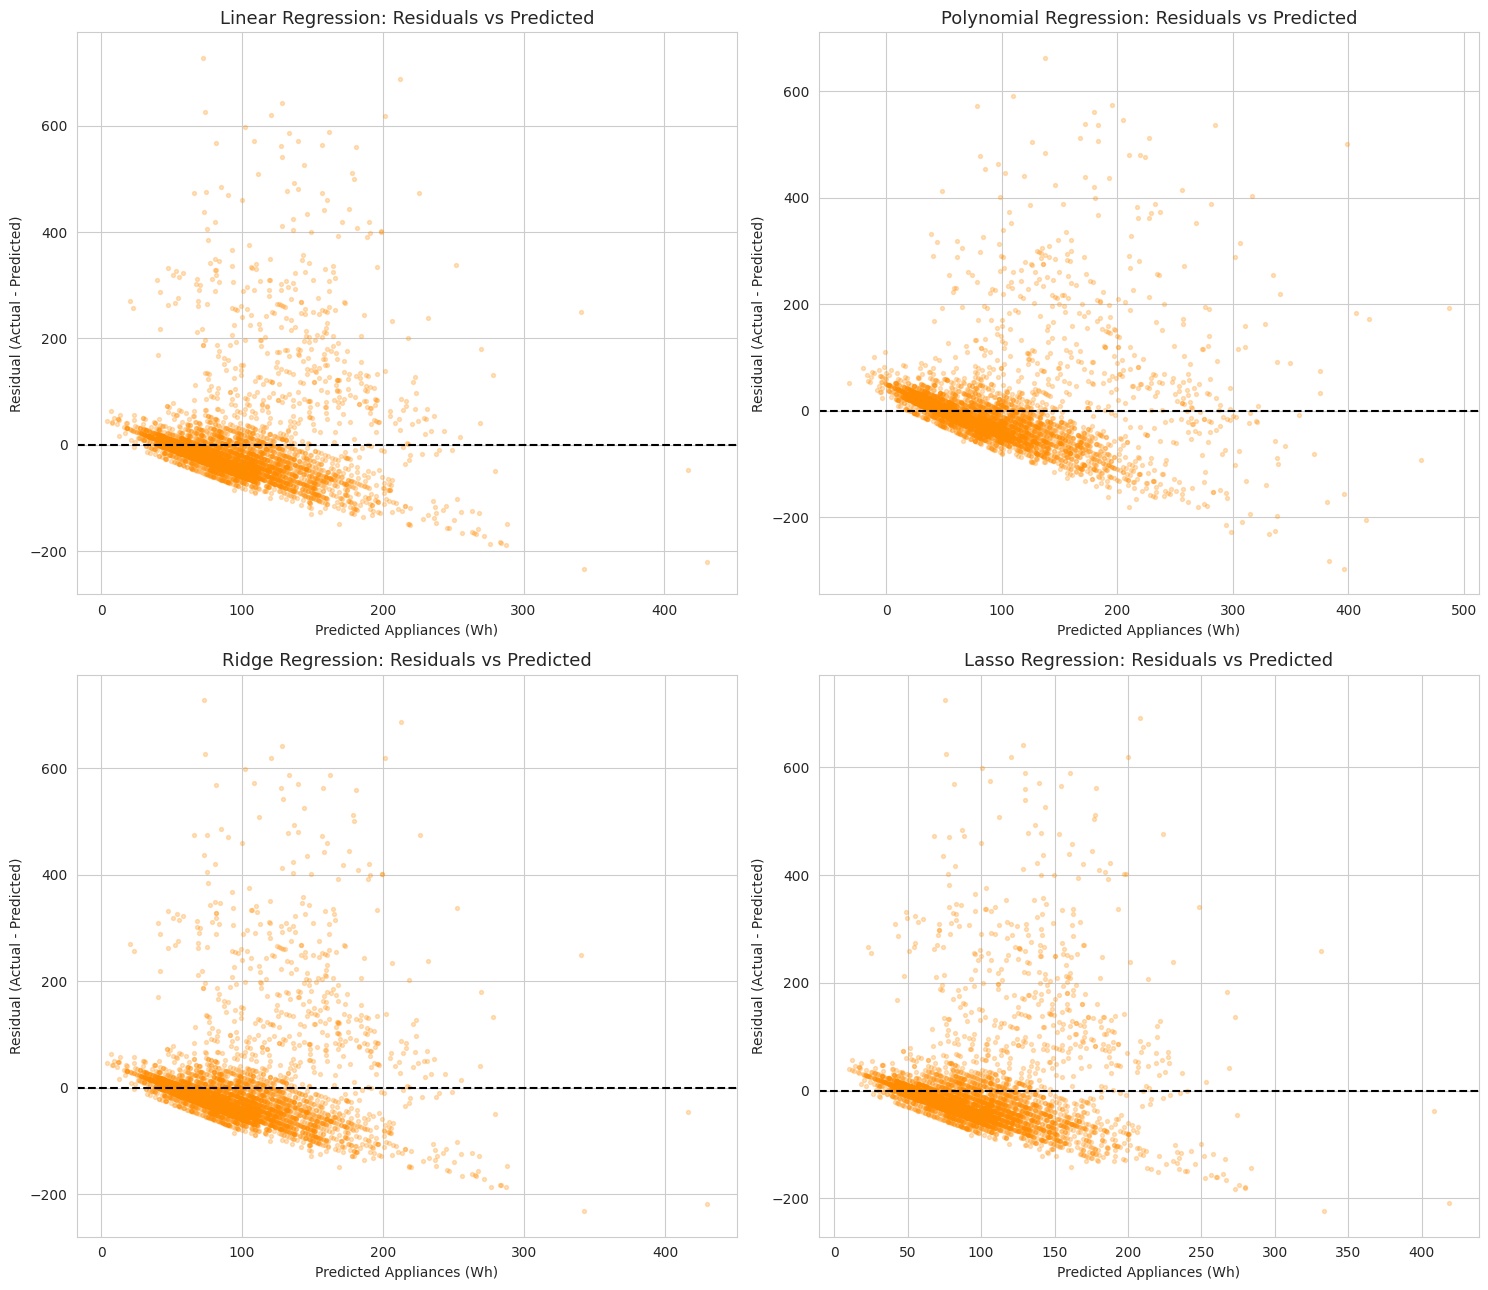

In [37]:
fig, axes = plt.subplots(2, 2, figsize=(15, 13))
axes = axes.flatten()

for ax, (model_name, y_pred) in zip(axes, regression_predictions.items()):
    residuals = y_test_reg.values - y_pred
    ax.scatter(y_pred, residuals, alpha=0.25, s=8, color="darkorange")
    ax.axhline(0, color="black", linestyle="--", linewidth=1.5)
    ax.set_title(f"{model_name}: Residuals vs Predicted", fontsize=13)
    ax.set_xlabel("Predicted Appliances (Wh)")
    ax.set_ylabel("Residual (Actual - Predicted)")

plt.tight_layout()
plt.show()

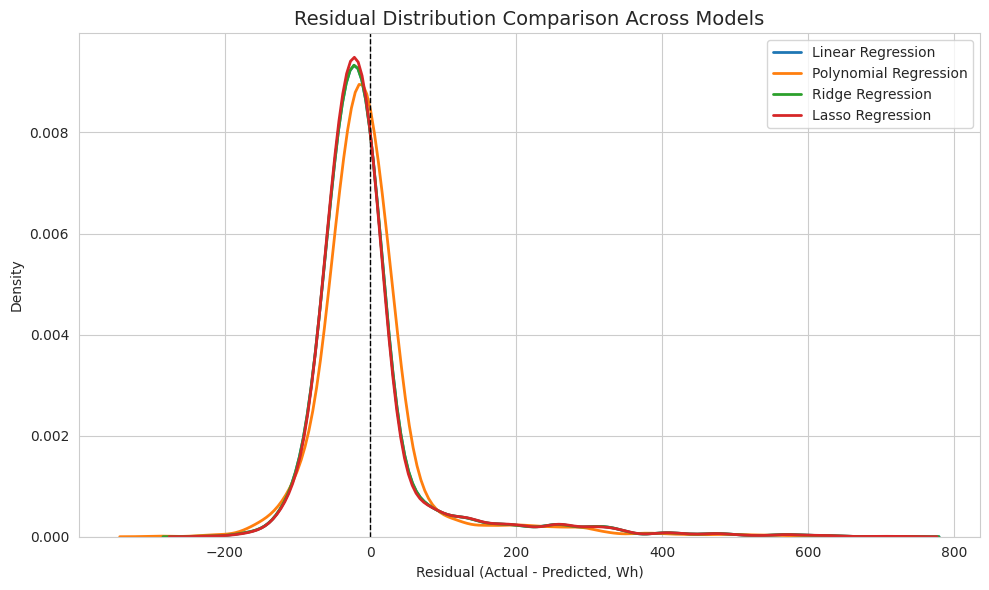

In [38]:
plt.figure(figsize=(10, 6))
for model_name, y_pred in regression_predictions.items():
    residuals = y_test_reg.values - y_pred
    sns.kdeplot(residuals, label=model_name, linewidth=2)

plt.axvline(0, color="black", linestyle="--", linewidth=1)
plt.title("Residual Distribution Comparison Across Models", fontsize=14)
plt.xlabel("Residual (Actual - Predicted, Wh)")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()

In [39]:
ridge_coefs = ridge_pipeline.named_steps["ridge"].coef_
lasso_coefs = lasso_pipeline.named_steps["lasso"].coef_

coef_comparison = pd.DataFrame({
    "Feature": X_reg.columns,
    "Ridge_Coefficient": ridge_coefs,
    "Lasso_Coefficient": lasso_coefs
})

coef_comparison["Abs_Lasso_Coefficient"] = coef_comparison["Lasso_Coefficient"].abs()
coef_comparison = coef_comparison.sort_values("Abs_Lasso_Coefficient", ascending=False).reset_index(drop=True)
coef_comparison

,Feature,Ridge_Coefficient,Lasso_Coefficient,Abs_Lasso_Coefficient
0,RH_1,60.409722,58.034779,58.034779
1,T3,56.257151,54.246231,54.246231
2,RH_2,-53.990560,-49.624825,49.624825
3,T6,44.394156,36.396166,36.396166
4,T2,-39.994884,-35.116000,35.116000
5,T_out,-43.039099,-23.967729,23.967729
6,RH_8,-18.786473,-19.030507,19.030507
7,month,-17.931383,-18.076963,18.076963
8,lights,14.763455,14.866853,14.866853
9,T9,-17.744545,-14.079181,14.079181


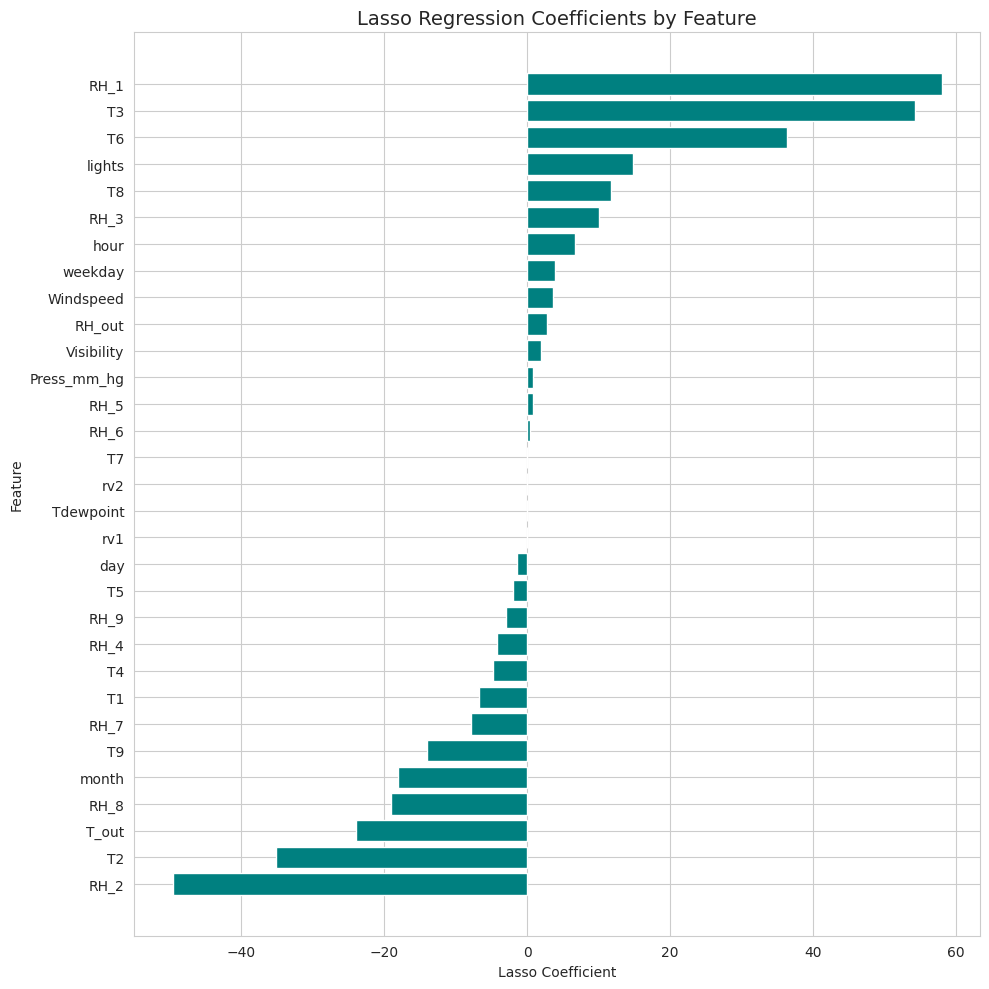

In [40]:
plt.figure(figsize=(10, 10))
sorted_by_lasso = coef_comparison.sort_values("Lasso_Coefficient")
plt.barh(sorted_by_lasso["Feature"], sorted_by_lasso["Lasso_Coefficient"], color="teal")
plt.title("Lasso Regression Coefficients by Feature", fontsize=14)
plt.xlabel("Lasso Coefficient")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [41]:
zero_or_near_zero = coef_comparison[coef_comparison["Abs_Lasso_Coefficient"] < 1e-3]
print("Features with Lasso coefficients closest to zero (effectively removed):")
print(zero_or_near_zero[["Feature", "Lasso_Coefficient"]])

Features with Lasso coefficients closest to zero (effectively removed):
      Feature  Lasso_Coefficient
27         T7                0.0
28        rv2                0.0
29  Tdewpoint                0.0
30        rv1                0.0


In [42]:
appliances_median = df["Appliances"].median()
df["High_Consumption"] = (df["Appliances"] >= appliances_median).astype(int)

print("Median Appliances threshold:", appliances_median)
print()
print("Class counts:")
print(df["High_Consumption"].value_counts())

Median Appliances threshold: 60.0

Class counts:
High_Consumption
1    12273
0     7462
Name: count, dtype: int64


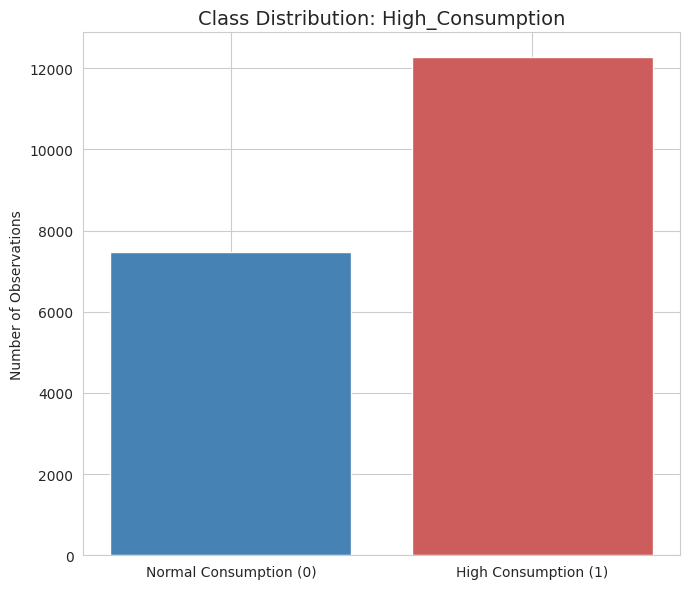

In [43]:
plt.figure(figsize=(7, 6))
class_counts = df["High_Consumption"].value_counts().sort_index()
plt.bar(["Normal Consumption (0)", "High Consumption (1)"], class_counts.values, color=["steelblue", "indianred"])
plt.title("Class Distribution: High_Consumption", fontsize=14)
plt.ylabel("Number of Observations")
plt.tight_layout()
plt.show()

In [44]:
X_clf = df.drop(columns=["Appliances", "High_Consumption"])
y_clf = df["High_Consumption"]

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=RANDOM_STATE, stratify=y_clf
)

scaler_clf = StandardScaler()
X_train_clf_scaled = scaler_clf.fit_transform(X_train_clf)
X_test_clf_scaled = scaler_clf.transform(X_test_clf)

print("Training set shape:", X_train_clf.shape)
print("Test set shape:", X_test_clf.shape)

Training set shape: (15788, 31)
Test set shape: (3947, 31)


In [45]:
def classification_metrics(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1 Score": f1_score(y_true, y_pred)
    }

classification_results = {}

## **Logistic Regression**



In [46]:
log_reg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
log_reg.fit(X_train_clf_scaled, y_train_clf)
y_pred_log = log_reg.predict(X_test_clf_scaled)
y_proba_log = log_reg.predict_proba(X_test_clf_scaled)[:, 1]

classification_results["Logistic Regression"] = classification_metrics(y_test_clf, y_pred_log)
classification_probabilities = {}
classification_probabilities["Logistic Regression"] = y_proba_log

print(classification_report(y_test_clf, y_pred_log, target_names=["Normal", "High"]))

              precision    recall  f1-score   support

      Normal       0.66      0.63      0.65      1492
        High       0.78      0.81      0.79      2455

    accuracy                           0.74      3947
   macro avg       0.72      0.72      0.72      3947
weighted avg       0.74      0.74      0.74      3947



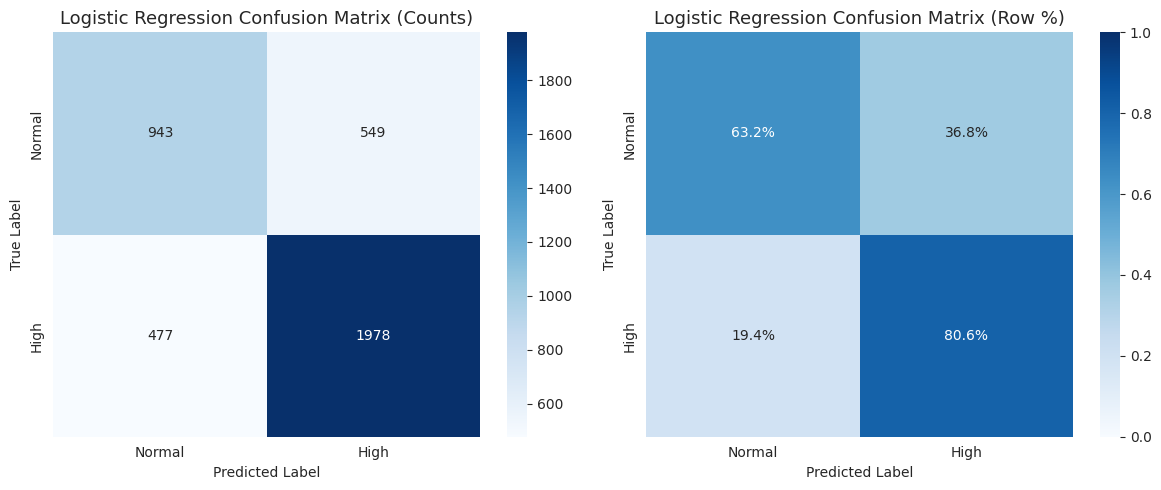

In [47]:
cm_log = confusion_matrix(y_test_clf, y_pred_log)
cm_log_norm = cm_log.astype(float) / cm_log.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(cm_log, annot=True, fmt="d", cmap="Blues", xticklabels=["Normal", "High"], yticklabels=["Normal", "High"], ax=axes[0])
axes[0].set_title("Logistic Regression Confusion Matrix (Counts)", fontsize=13)
axes[0].set_xlabel("Predicted Label")
axes[0].set_ylabel("True Label")

sns.heatmap(cm_log_norm, annot=True, fmt=".1%", cmap="Blues", xticklabels=["Normal", "High"], yticklabels=["Normal", "High"], ax=axes[1], vmin=0, vmax=1)
axes[1].set_title("Logistic Regression Confusion Matrix (Row %)", fontsize=13)
axes[1].set_xlabel("Predicted Label")
axes[1].set_ylabel("True Label")

plt.tight_layout()
plt.show()

## **KNN Classification**

In [48]:
knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(X_train_clf_scaled, y_train_clf)
y_pred_knn = knn.predict(X_test_clf_scaled)
y_proba_knn = knn.predict_proba(X_test_clf_scaled)[:, 1]

classification_results["KNN (k=7)"] = classification_metrics(y_test_clf, y_pred_knn)
classification_probabilities["KNN (k=7)"] = y_proba_knn

print(classification_report(y_test_clf, y_pred_knn, target_names=["Normal", "High"]))

              precision    recall  f1-score   support

      Normal       0.72      0.74      0.73      1492
        High       0.84      0.82      0.83      2455

    accuracy                           0.79      3947
   macro avg       0.78      0.78      0.78      3947
weighted avg       0.79      0.79      0.79      3947



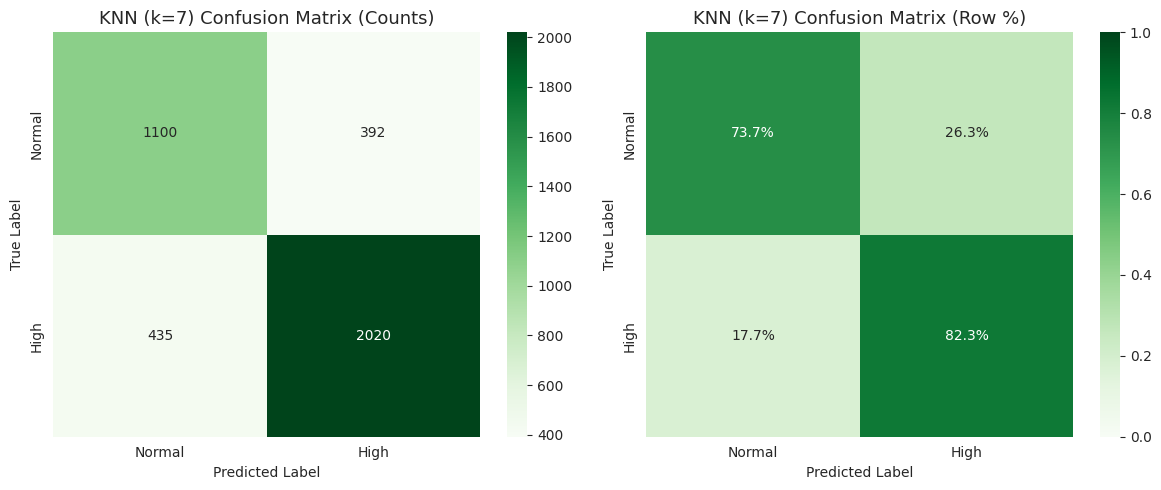

In [49]:
cm_knn = confusion_matrix(y_test_clf, y_pred_knn)
cm_knn_norm = cm_knn.astype(float) / cm_knn.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(cm_knn, annot=True, fmt="d", cmap="Greens", xticklabels=["Normal", "High"], yticklabels=["Normal", "High"], ax=axes[0])
axes[0].set_title("KNN (k=7) Confusion Matrix (Counts)", fontsize=13)
axes[0].set_xlabel("Predicted Label")
axes[0].set_ylabel("True Label")

sns.heatmap(cm_knn_norm, annot=True, fmt=".1%", cmap="Greens", xticklabels=["Normal", "High"], yticklabels=["Normal", "High"], ax=axes[1], vmin=0, vmax=1)
axes[1].set_title("KNN (k=7) Confusion Matrix (Row %)", fontsize=13)
axes[1].set_xlabel("Predicted Label")
axes[1].set_ylabel("True Label")

plt.tight_layout()
plt.show()

## **KNN Hyperparameter Analysis**

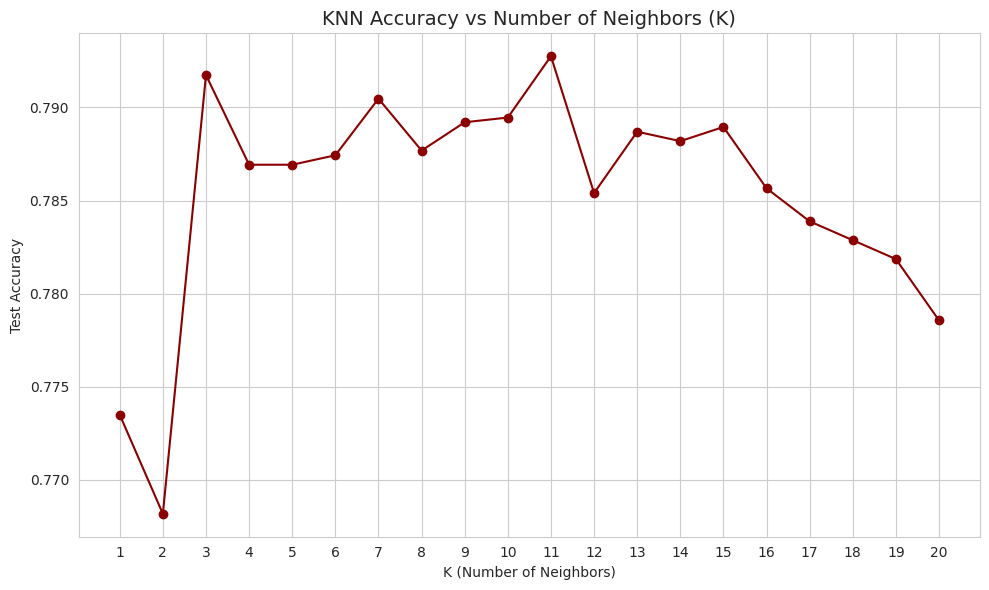

In [50]:
k_values = range(1, 21)
k_accuracies = []

for k in k_values:
    knn_k = KNeighborsClassifier(n_neighbors=k)
    knn_k.fit(X_train_clf_scaled, y_train_clf)
    y_pred_k = knn_k.predict(X_test_clf_scaled)
    k_accuracies.append(accuracy_score(y_test_clf, y_pred_k))

plt.figure(figsize=(10, 6))
plt.plot(list(k_values), k_accuracies, marker="o", color="darkred")
plt.title("KNN Accuracy vs Number of Neighbors (K)", fontsize=14)
plt.xlabel("K (Number of Neighbors)")
plt.ylabel("Test Accuracy")
plt.xticks(list(k_values))
plt.grid(True)
plt.tight_layout()
plt.show()

In [51]:
best_k = list(k_values)[int(np.argmax(k_accuracies))]
best_k_accuracy = max(k_accuracies)
print("Best K value:", best_k)
print("Best K accuracy:", best_k_accuracy)

Best K value: 11
Best K accuracy: 0.7927539903724348


In [52]:
knn_best = KNeighborsClassifier(n_neighbors=best_k)
knn_best.fit(X_train_clf_scaled, y_train_clf)
y_pred_knn_best = knn_best.predict(X_test_clf_scaled)
y_proba_knn_best = knn_best.predict_proba(X_test_clf_scaled)[:, 1]

classification_results[f"KNN (best k={best_k})"] = classification_metrics(y_test_clf, y_pred_knn_best)
classification_probabilities[f"KNN (best k={best_k})"] = y_proba_knn_best

print(classification_report(y_test_clf, y_pred_knn_best, target_names=["Normal", "High"]))

              precision    recall  f1-score   support

      Normal       0.72      0.74      0.73      1492
        High       0.84      0.83      0.83      2455

    accuracy                           0.79      3947
   macro avg       0.78      0.78      0.78      3947
weighted avg       0.79      0.79      0.79      3947



## **ROC and Precision-Recall Curves**

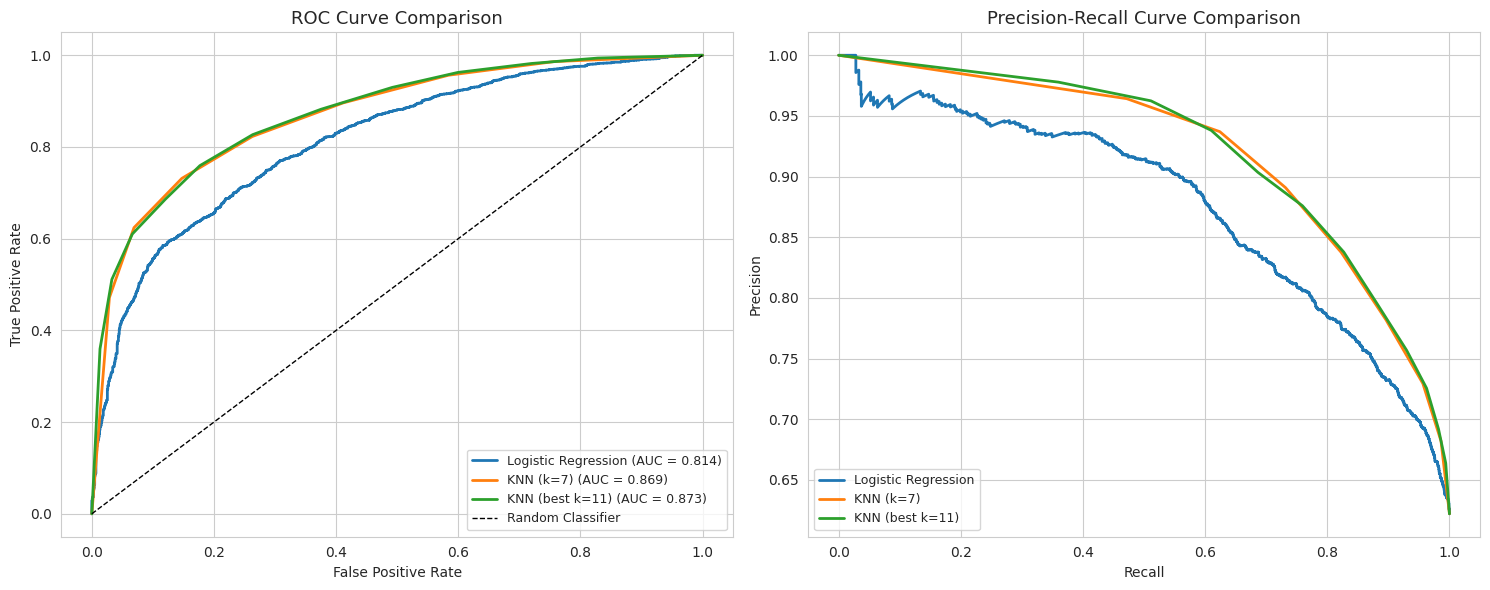

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for model_name, y_proba in classification_probabilities.items():
    fpr, tpr, _ = roc_curve(y_test_clf, y_proba)
    roc_auc = auc(fpr, tpr)
    axes[0].plot(fpr, tpr, linewidth=2, label=f"{model_name} (AUC = {roc_auc:.3f})")

axes[0].plot([0, 1], [0, 1], color="black", linestyle="--", linewidth=1, label="Random Classifier")
axes[0].set_title("ROC Curve Comparison", fontsize=13)
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend(loc="lower right", fontsize=9)

for model_name, y_proba in classification_probabilities.items():
    precision, recall, _ = precision_recall_curve(y_test_clf, y_proba)
    axes[1].plot(recall, precision, linewidth=2, label=model_name)

axes[1].set_title("Precision-Recall Curve Comparison", fontsize=13)
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend(loc="lower left", fontsize=9)

plt.tight_layout()
plt.show()

## **Classification Model Comparison**

In [54]:
classification_comparison = pd.DataFrame(classification_results).T
classification_comparison = classification_comparison[["Accuracy", "Precision", "Recall", "F1 Score"]]
classification_comparison

,Accuracy,Precision,Recall,F1 Score
Logistic Regression,0.740056,0.782746,0.805703,0.794059
KNN (k=7),0.790474,0.837479,0.822811,0.830080
KNN (best k=11),0.792754,0.837804,0.826884,0.832308


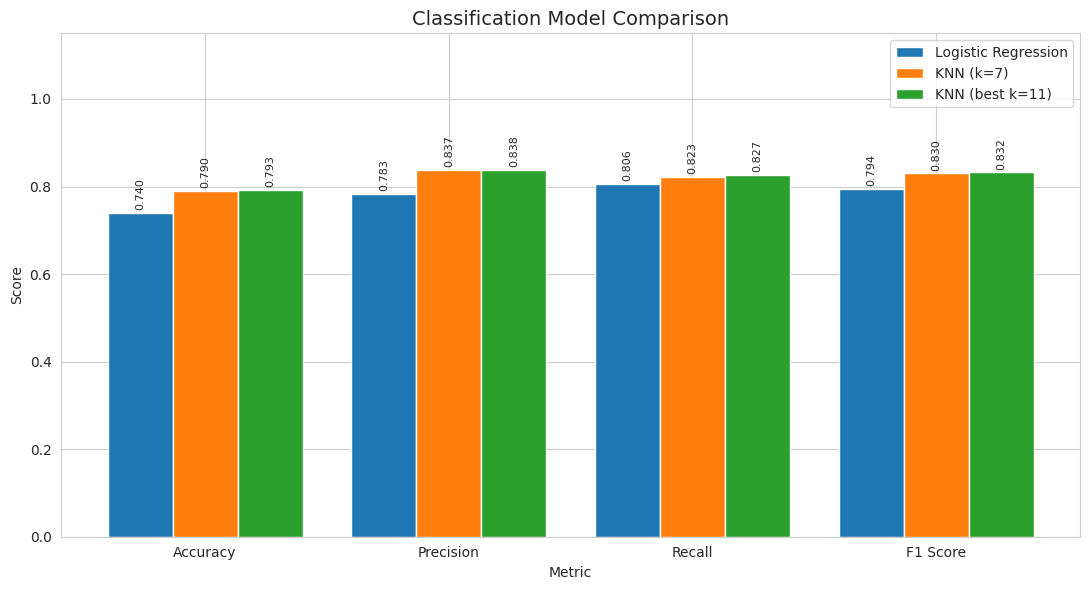

In [55]:
metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1 Score"]
x = np.arange(len(metrics_to_plot))
width = 0.8 / len(classification_comparison)

plt.figure(figsize=(11, 6))
for i, model_name in enumerate(classification_comparison.index):
    values = classification_comparison.loc[model_name, metrics_to_plot].values
    bars = plt.bar(x + i * width, values, width=width, label=model_name)
    plt.bar_label(bars, fmt="%.3f", padding=2, fontsize=8, rotation=90)

plt.title("Classification Model Comparison", fontsize=14)
plt.xlabel("Metric")
plt.ylabel("Score")
plt.ylim(0, 1.15)
plt.xticks(x + width * (len(classification_comparison) - 1) / 2, metrics_to_plot)
plt.legend()
plt.tight_layout()
plt.show()

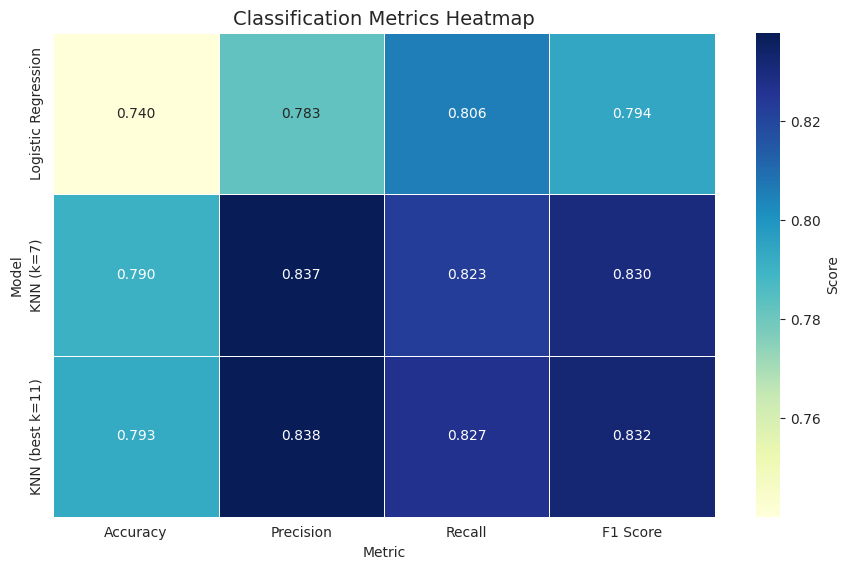

In [56]:
plt.figure(figsize=(9, 4 + 0.6 * len(classification_comparison)))
sns.heatmap(classification_comparison.astype(float), annot=True, fmt=".3f", cmap="YlGnBu", linewidths=0.5, cbar_kws={"label": "Score"})
plt.title("Classification Metrics Heatmap", fontsize=14)
plt.xlabel("Metric")
plt.ylabel("Model")
plt.tight_layout()
plt.show()

In [57]:
best_classification_model = classification_comparison["F1 Score"].idxmax()
print("Best classification model based on F1 score:", best_classification_model)
print(classification_comparison.loc[best_classification_model])

Best classification model based on F1 score: KNN (best k=11)
Accuracy     0.792754
Precision    0.837804
Recall       0.826884
F1 Score     0.832308
Name: KNN (best k=11), dtype: float64


## **Logistic Regression Feature Analysis**

In [58]:
log_reg_coefs = log_reg.coef_[0]

logreg_coef_df = pd.DataFrame({
    "Feature": X_clf.columns,
    "Coefficient": log_reg_coefs
})
logreg_coef_df["Absolute Coefficient"] = logreg_coef_df["Coefficient"].abs()
logreg_coef_df = logreg_coef_df.sort_values("Absolute Coefficient", ascending=False).reset_index(drop=True)
logreg_coef_df

,Feature,Coefficient,Absolute Coefficient
0,RH_1,1.337522,1.337522
1,T8,1.117717,1.117717
2,RH_8,-0.853336,0.853336
3,RH_2,-0.848929,0.848929
4,T6,0.826315,0.826315
5,T3,0.806495,0.806495
6,lights,0.737507,0.737507
7,T7,-0.577184,0.577184
8,T2,-0.569489,0.569489
9,T9,-0.472074,0.472074


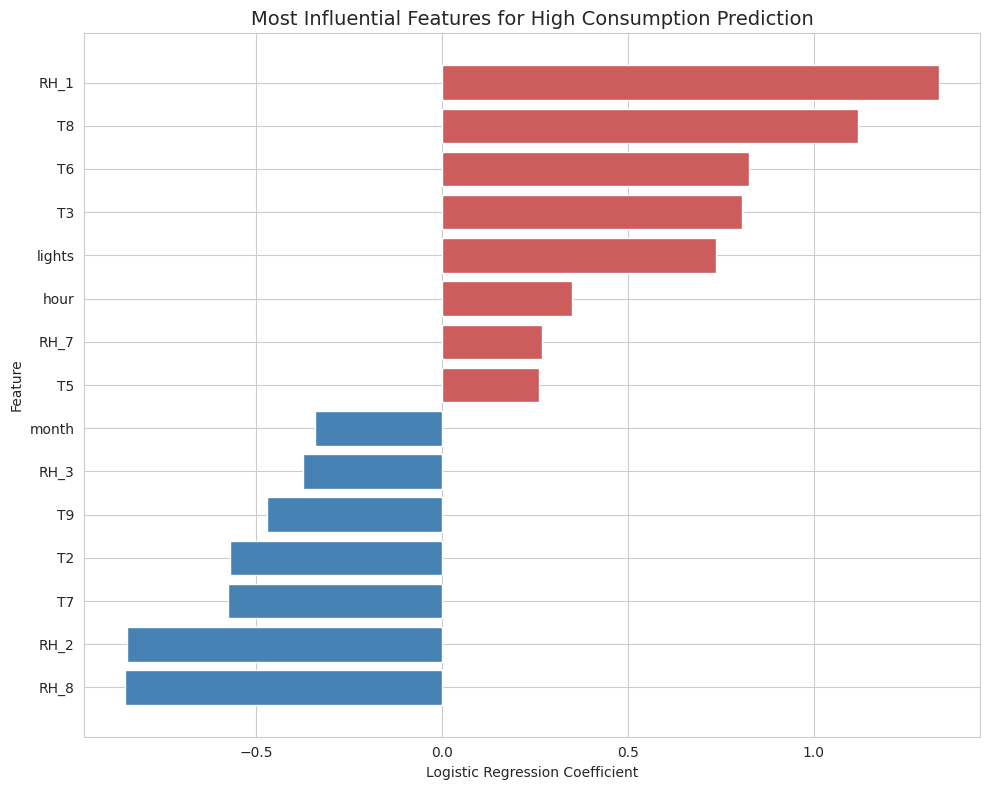

In [59]:
top_features = logreg_coef_df.head(15).sort_values("Coefficient")

plt.figure(figsize=(10, 8))
colors = ["indianred" if c > 0 else "steelblue" for c in top_features["Coefficient"]]
plt.barh(top_features["Feature"], top_features["Coefficient"], color=colors)
plt.title("Most Influential Features for High Consumption Prediction", fontsize=14)
plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

Features with **positive** coefficients push the prediction towards `High Consumption` (class 1) as their value increases, while features with **negative** coefficients push the prediction towards `Normal Consumption` (class 0). The magnitude of the coefficient (after scaling) reflects how strongly each feature influences the model's decision.

In [60]:
correlation_with_appliances = df.corr()["Appliances"].drop(["Appliances", "High_Consumption"]).sort_values(ascending=False)
top_positive_corr = correlation_with_appliances.head(5)
top_negative_corr = correlation_with_appliances.tail(5)

print("Top 5 positive correlations with Appliances:")
print(top_positive_corr)
print()
print("Top 5 negative correlations with Appliances:")
print(top_negative_corr)

Top 5 positive correlations with Appliances:
hour      0.216792
lights    0.197278
T2        0.120073
T6        0.117638
T_out     0.099155
Name: Appliances, dtype: float64

Top 5 negative correlations with Appliances:
RH_7     -0.055642
RH_2     -0.060465
RH_6     -0.083178
RH_8     -0.094039
RH_out   -0.152282
Name: Appliances, dtype: float64


In [61]:
top_lasso_features = coef_comparison.sort_values("Abs_Lasso_Coefficient", ascending=False).head(5)["Feature"].tolist()
top_logreg_features = logreg_coef_df.head(5)["Feature"].tolist()

poly_vs_linear_r2_gain = regression_results["Polynomial Regression"]["R2"] - regression_results["Linear Regression"]["R2"]

print("Top 5 features by Lasso coefficient magnitude:", top_lasso_features)
print("Top 5 features by Logistic Regression coefficient magnitude:", top_logreg_features)
print("R2 gain of Polynomial Regression over Linear Regression:", round(poly_vs_linear_r2_gain, 4))
print("Best regression model:", best_regression_model)
print("Best classification model:", best_classification_model)
print("Best K value found for KNN:", best_k)
print("Peak average hourly consumption occurs at hour:", int(hourly_avg.idxmax()), "with", round(hourly_avg.max(), 2), "Wh")
print("Lowest average hourly consumption occurs at hour:", int(hourly_avg.idxmin()), "with", round(hourly_avg.min(), 2), "Wh")

Top 5 features by Lasso coefficient magnitude: ['RH_1', 'T3', 'RH_2', 'T6', 'T2']
Top 5 features by Logistic Regression coefficient magnitude: ['RH_1', 'T8', 'RH_8', 'RH_2', 'T6']
R2 gain of Polynomial Regression over Linear Regression: 0.1506
Best regression model: Polynomial Regression
Best classification model: KNN (best k=11)
Best K value found for KNN: 11
Peak average hourly consumption occurs at hour: 18 with 190.36 Wh
Lowest average hourly consumption occurs at hour: 3 with 48.24 Wh


Based on the computations above:

- **Strongest correlations with `Appliances`** come from the variables printed above; indoor temperature/humidity readings and the `lights` variable tend to show the most notable relationships with appliance energy use, while outdoor weather variables tend to correlate more weakly.
- **Lasso-selected predictors:** the top features ranked by absolute Lasso coefficient (printed above) are the ones Lasso considers most predictive of `Appliances`, while features with near-zero coefficients (Section 14) were effectively excluded by the L1 penalty.
- **Logistic Regression predictors:** the top features ranked by absolute coefficient (printed above and in Section 20) drive the probability of an observation being classified as `High Consumption`.
- **Polynomial vs Linear Regression:** the R² gain computed above shows whether allowing quadratic and interaction terms actually improved fit over plain Linear Regression on this dataset, or whether it mainly added complexity without much benefit.
- **Ridge vs Lasso:** Ridge distributes weight across many correlated features and rarely zeroes any out, while Lasso aggressively shrinks unimportant features to exactly zero, providing a form of built-in feature selection (Section 14).
- **Best regression model:** identified programmatically above as the model with the highest R² / lowest RMSE on the test set.
- **Best classification model:** identified programmatically above as the model with the highest F1-score on the test set.
- **Best K for KNN:** identified via the K-vs-accuracy sweep in Section 18.
- **Hourly patterns:** the peak and lowest average hourly consumption values printed above indicate when household appliance usage is typically highest and lowest during the day, consistent with typical daily routines (e.g., higher usage around meal times/evenings, lower usage overnight).